In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv


# **Forecasting Cinema Audience Count — A Time-Series Project**

## Project Description:

* This project focuses on forecasting cinema audience count using historical booking and sales data from two major sources — booknow_booking, an online movie ticket booking and aggregation platform, and CinePOS_booking, a point-of-sale system used in theaters for tracking on-site ticket sales. 

* The primary goal is to develop a data-driven machine learning model that accurately predicts the number of audience members expected for future show dates at various theaters. By integrating time-series forecasting techniques, the project aims to capture temporal patterns, seasonal trends, and audience behavior across different theaters and show dates.

* The dataset combines online pre-booking trends and offline sales patterns, enabling comprehensive modeling of real-world cinema attendance. Accurate forecasting can assist theater managers in optimizing staffing, inventory, and scheduling decisions, while also helping booking platforms enhance their promotional strategies. The final model will generate audience count predictions for future dates based on the Book_theater_id and show_date provided in the test dataset (Sample submission).


## Data Preprocessing:

**1. Initial Data Cleaning:**

The first step involves cleaning and standardizing the raw data collected from BookNow and CinePOS platforms.

Typical cleaning tasks include:

* Removing duplicate records or invalid entries (e.g., negative audience counts, incorrect dates).
* Ensuring consistent column names, data formats, and date-time types.
* Handling missing or mismatched records during data integration.
* Handling Outlier detection.

This ensures a uniform, error-free dataset ready for analysis.

**2. Missing Value Imputation & Smoothing**

Missing data is common in real-world booking systems due to system downtimes or incomplete reporting.
Key techniques include, Mean, Median, Standard Deviation, Constant Values.
These methods help preserve temporal continuity and improve the reliability of model inputs.

**3. Data Scaling / Normalization**

Feature scaling ensures that numerical variables are within a comparable range, helping the forecasting model converge efficiently.
Common methods used:

* Min-Max Scaling to scale values between 0 and 1.
* Standard Scaling (Z-score normalization) to center data with mean = 0 and standard deviation = 1.
This step is essential when combining features with different magnitudes (e.g., ticket count vs. lead time in days).


## Feature Engineering

**1. Time-Series Feature Engineering**

Feature engineering is the heart of time-series forecasting. The following temporal features can significantly enhance the model’s predictive power:

*a) Lag Features*

Lag features represent past values of the target variable (audience count) to capture autocorrelation.

Example: lag_1, lag_7, lag_14 — audience count from previous day, week, or two weeks. (Lags: 1, 7, 14, 30)

*b) Rolling Statistics*

Rolling or window-based features summarize recent trends:

rolling_mean_7, rolling_median_7, rolling_std_7 — 7-day moving averages or standard deviations. (Rolling means/medians: 7, 14, 30)

Capture local seasonality and momentum patterns in attendance.

*c) Calendar Features*

Calendar-based time components often influence audience behavior: (Date features: month, week, weekend, holiday flag)

* day_of_week
* month
* year
* day_of_year
* week_of_year
* holiday
* weekend
* Period (YYYY-MM) 

These features help models learn weekly and seasonal patterns, such as weekend surges or festive peaks.

**2. Booking Lead Time:**

Understanding booking behavior from BookNow helps estimate audience intent.
Booking Lead Time = show_date_time - booking_date_time - (longer lead time may indicate high-demand shows)

These behavioral metrics add depth to the forecasting model by reflecting user decision patterns.

**3. Aggregation Features (Theater-level Statistics)**

To capture theater-specific performance and audience trends:


* Average audience count per theater: mean attendance for a given Book_theater_id.
* Standard deviation of audience count per theater: measures variability and stability in attendance.
* Average/Median audience count by show_date: identifies day-specific audience trends across theaters.


These features help models generalize across different theaters and days.

## Use time-based validation

* we split the training and validation set. for traing set show_date include range from Jan 1, 2023 to Feb 28, 2024. and Test Data set (Sample Submission) show_date include range from Jan 1, 2024 to Feb 28, 2024.

* model to understand the pattern, we used the train_data for model training, The date starts from 2023-03-01 to 2023-04-30.

## Evaluation & submission:

* score with MAE,MSE, RMSE and domain-appropriate measures (MASE or RMSLE if skewed).
* we followed R2 score for model accuracy (training, validation, and testing).

For submission, generate predictions for 2024-03-01 → 2024-04-22, mask excluded closed days, and create `submission.csv` format for final prediction.

## Feature Selection

Techniques:

* mutual_info_regression
* RFE
* VarianceThreshold
* Correaltion (X,y)
* featuresfeature_importances_(highest to lowest)
* permutation_importance



## Base models

**Linear models:**
Linear models are simple yet powerful baseline predictors. They help identify whether relationships between features and audience count are approximately linear.

LinearRegression, 
Ridge, 
Lasso, 
SGDRegressor

**Ensemble models:**
Ensemble models combine multiple decision trees to improve predictive power and robustness against noise.


RandomForestRegressor
GradientBoostingRegressor
HistGradientBoostingRegressor

**Advanced models:**
These models are optimized gradient-boosting frameworks known for their speed, scalability, and predictive accuracy.

XGBRegressor (XGBoost)
LGBMRegressor (LightGBM)

**Tree model**:
 A single, non-linear model that recursively splits data based on feature thresholds. Simple to visualize and interpret but prone to overfitting if not pruned properly. Useful as a baseline before moving to ensemble tree methods.
  
DecisionTreeRegressor

**Neural network: (Multi-Layer Perceptron)**
 A feedforward neural network capable of learning nonlinear relationships.
 MLPRegressor

## Summary of the Project:
1. Data Loading

2. Exploratory Data Analysis (EDA)

3. Project Data Analysis Begins

3.1 Date Features Extraction

3.2 Computing Mean, Median, Std of Audience

3.3 Compute Average Audience Count Per

3.4 Day of Week of Audience Count

3.5 Unique Theater id's on period:

3.6 Tickets Booked Count on Book id's

3.7 Encoding for Theater Types

3.8 Cinepos Theater Tickets Sold Info

3.9 Lag and Rolling Mean Features

3.10 Train and Validation Splits for Time Series

3.11 Heatmap – Correlation Map

3.12 Redundant Features Removing

3.12.1 Input Features Correlation

4. Feature Selection Methods

4.1 Variancethreshold

4.2 MI-regression

4.3 RFE feature selection

4.4 Feature Importances-Ensemble Models

4.5 Permutation Importance- HGBR

5. Preprocessing - scaling

6. Model Training And Evaluating

6.1 Visualizing The Model Performance

6.2. Model Performance Comparison

7. Hyper-Parameter Tuning

8. Best Model Selection

9. Kaggle Submission


## IMPORTING LIBARIES

In [45]:
# IMPUTATION
from sklearn.impute import SimpleImputer, KNNImputer

# PREPROCESSING
from sklearn.preprocessing import (StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler,LabelEncoder, OneHotEncoder, OrdinalEncoder, 
PolynomialFeatures)

# PIPELINE & TRANSFORMERS
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_selector, make_column_transformer

# DATA SPLITTING & CROSS-VALIDATION
from sklearn.model_selection import (train_test_split, KFold, cross_val_score, cross_validate, GridSearchCV, RandomizedSearchCV)


# FEATURE SELECTION
from sklearn.feature_selection import (SelectKBest, SelectPercentile, RFE, RFECV, SequentialFeatureSelector, SelectFromModel, 
VarianceThreshold, mutual_info_regression)

from sklearn.inspection import permutation_importance

# FEATURE EXTRACTION
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_extraction import DictVectorizer

# REGRESSION MODELS
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor, HuberRegressor)
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor,
    ExtraTreesRegressor, BaggingRegressor, VotingRegressor, HistGradientBoostingRegressor)

from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor

#High-performance gradient boosting frameworks
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# METRICS
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score)

# Statistics & Time Series Analysis
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


import warnings
warnings.filterwarnings('ignore')

#Data Manipulation
import numpy as np
import pandas as pd
from scipy import stats

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns


# 1. DATA LOADING...

In [80]:
# Theatre information
cinepos_theaters = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv')
booknow_theaters = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv')
theater_relation = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv')

# Booking data
cinepos_booking = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv')
booknow_booking = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv')
    
# Target variable and calendar (Base Dataset)
booknow_visits = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv')

# Dat Info
date_info = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv')
    
# Sample submission file (test data)
sample_submission = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv')

### 1.1 datasets copy for Visualization


In [81]:
booknow_theaters1 = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv')
booknow_booking1 = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv')
    
# Target variable and calendar (Base Dataset)
train_data_copy = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv')
test_data_copy = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv')

In [82]:
test_data_copy['book_theater_id']=test_data_copy['ID'].str[:10]
test_data_copy['show_date']=test_data_copy['ID'].str[-10:]
test_data_copy['show_date']=pd.to_datetime(test_data_copy['show_date'])

def date_features(df):
    df=df.copy()
    df['show_date']=pd.to_datetime(df['show_date'])
    df['day_of_week']=df['show_date'].dt.dayofweek
    df['is_weekend']=(df['day_of_week']>=4).astype(int)
    df['month']=df['show_date'].dt.month
    df['period']=df['show_date'].dt.to_period('M')
    return df

train_data_copy=date_features(train_data_copy)
test_data_copy=date_features(test_data_copy)
print(train_data_copy.shape)
print(test_data_copy.shape)

(214046, 7)
(38062, 8)


### 1.3 SHAPE OF THE ALL THE DATASETS

In [83]:
print("cinepos_theaters",cinepos_theaters.shape)
print("booknow_theaters",booknow_theaters.shape)
print("theater_relation",theater_relation.shape)

print("cinepos_booking",cinepos_booking.shape)
print("booknow_booking",booknow_booking.shape)

print("booknow_visits",booknow_visits.shape)
print("date_info",date_info.shape)
print("sample_submission",sample_submission.shape)

cinepos_theaters (4690, 5)
booknow_theaters (829, 5)
theater_relation (150, 2)
cinepos_booking (1641966, 4)
booknow_booking (68336, 4)
booknow_visits (214046, 3)
date_info (547, 2)
sample_submission (38062, 2)


**Insights**
<p> Booknowvists dataset is considered as the base dataset and sample submission dataset as the test dataset. 
    BookNow: an online booking and CinePOS: a point-of-sale (POS) system installed at theaters that monitors on-site ticket sales.   mo</p>

# 2. Exploratory Data Analysis (EDA)

* process that includes understanding, cleaning, summarizing, and exploring the dataset — both numerically and graphically

### 2.1 Duplicates identification

In [84]:
def count_duplicates(df, df_name):
    duplicates_count=df.duplicated().sum()
    print(f" no of duplicates rows in {df_name}: {duplicates_count}")

count_duplicates(cinepos_theaters,"cinepos_theaters")
count_duplicates(booknow_theaters,"booknow_theaters")
count_duplicates(theater_relation,"theater_relation")

count_duplicates(cinepos_booking,"cinepos_booking")
count_duplicates(booknow_booking,"booknow_booking",)

count_duplicates(booknow_visits,"booknow_visits")
count_duplicates(date_info,"date_info")
count_duplicates(sample_submission,"sample_submission")

 no of duplicates rows in cinepos_theaters: 0
 no of duplicates rows in booknow_theaters: 354
 no of duplicates rows in theater_relation: 0
 no of duplicates rows in cinepos_booking: 12541
 no of duplicates rows in booknow_booking: 2042
 no of duplicates rows in booknow_visits: 10
 no of duplicates rows in date_info: 0
 no of duplicates rows in sample_submission: 0


In [85]:
booknow_theaters.drop_duplicates(inplace=True)
cinepos_booking.drop_duplicates(inplace=True)
booknow_booking.drop_duplicates(inplace=True)
booknow_visits.drop_duplicates(inplace=True)

print("Duplicates removed from affected datasets")


count_duplicates(cinepos_theaters,"cinepos_theaters")
count_duplicates(booknow_theaters,"booknow_theaters")
count_duplicates(theater_relation,"theater_relation")

count_duplicates(cinepos_booking,"cinepos_booking")
count_duplicates(booknow_booking,"booknow_booking",)

count_duplicates(booknow_visits,"booknow_visits")
count_duplicates(date_info,"date_info")
count_duplicates(sample_submission,"sample_submission")

print("Duplicates counts of datasets after Removed duplicated")

Duplicates removed from affected datasets
 no of duplicates rows in cinepos_theaters: 0
 no of duplicates rows in booknow_theaters: 0
 no of duplicates rows in theater_relation: 0
 no of duplicates rows in cinepos_booking: 0
 no of duplicates rows in booknow_booking: 0
 no of duplicates rows in booknow_visits: 0
 no of duplicates rows in date_info: 0
 no of duplicates rows in sample_submission: 0
Duplicates counts of datasets after Removed duplicated


### 2.2 Handling Outliers

In [86]:
Q1=train_data_copy['audience_count'].quantile(0.25)
Q3=train_data_copy['audience_count'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-(1.5*IQR)
upper_bound=Q3+(1.5*IQR)

outliers=train_data_copy[(train_data_copy['audience_count']<lower_bound)|(train_data_copy['audience_count']>upper_bound)]
print(outliers.shape)

print(outliers.book_theater_id.nunique())
print(outliers.show_date.nunique())
print(f" Q1: {Q1}, Q3: {Q3}, IQR:{IQR}")
print("lower_bound",lower_bound)
print("upper_bound",upper_bound)

(5589, 7)
408
420
 Q1: 18.0, Q3: 58.0, IQR:40.0
lower_bound -42.0
upper_bound 118.0


In [87]:
outliers.head()

,book_theater_id,show_date,audience_count,day_of_week,is_weekend,month,period
140,book_00001,2023-07-01,122,5,1,7,2023-07
639,book_00003,2023-07-10,132,0,0,7,2023-07
1315,book_00005,2023-09-18,122,0,0,9,2023-09
1404,book_00005,2023-12-16,120,5,1,12,2023-12
1418,book_00005,2023-12-30,134,5,1,12,2023-12


In [88]:
outliers.day_of_week.value_counts()  #0-monday, 5- saturday, 6-sunday

day_of_week
6    1720
0    1227
5    1024
4     470
3     453
1     385
2     310
Name: count, dtype: int64

In [89]:
outliers.is_weekend.value_counts(normalize=True)*100

is_weekend
1    57.505815
0    42.494185
Name: proportion, dtype: float64

In [90]:
outliers.month.value_counts()

month
12    906
2     627
1     612
7     584
10    498
11    437
9     419
8     376
3     352
4     296
5     265
6     217
Name: count, dtype: int64

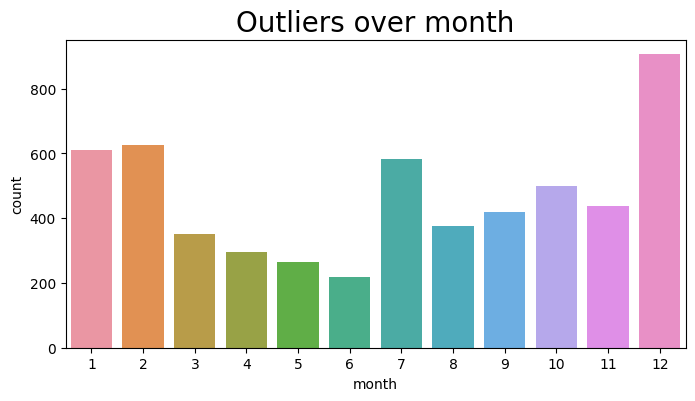

In [118]:
plt.figure(figsize=(8,4))
sns.countplot(data=outliers, x='month')
plt.title("Outliers over month", fontsize=20)
plt.show()

In [91]:
top10_highest_audience_count=sorted(train_data_copy.audience_count.unique(), reverse=True)[:10]
least10_lowest_audience_count=sorted(train_data_copy.audience_count.unique(), reverse=False)[:10]

print(f" top10_highest_audience_count: {top10_highest_audience_count},least10_lowest_audience_count: {least10_lowest_audience_count} ")
print(f" median count:{train_data_copy.audience_count.median()}, mean count: {train_data_copy.audience_count.mean()}")
print(f" std count:{train_data_copy.audience_count.std()}, var count: {train_data_copy.audience_count.var()}")

print("lower_bound",lower_bound)
print("upper_bound",upper_bound)

 top10_highest_audience_count: [1350, 1254, 1028, 818, 744, 738, 702, 696, 656, 650],least10_lowest_audience_count: [2, 4, 6, 8, 10, 12, 14, 16, 18, 20] 
 median count:34.0, mean count: 41.61656840118479
 std count:32.83491752296652, var count: 1078.131808740014
lower_bound -42.0
upper_bound 118.0


In [92]:
print(train_data_copy[train_data_copy['audience_count']>118].shape)
print(train_data_copy[train_data_copy['audience_count']<=118].shape)

(5589, 7)
(208457, 7)


### 2.3 Identify the data types of Train and Test datasets

In [93]:
train_data_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214046 entries, 0 to 214045
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   book_theater_id  214046 non-null  object        
 1   show_date        214046 non-null  datetime64[ns]
 2   audience_count   214046 non-null  int64         
 3   day_of_week      214046 non-null  int32         
 4   is_weekend       214046 non-null  int64         
 5   month            214046 non-null  int32         
 6   period           214046 non-null  period[M]     
dtypes: datetime64[ns](1), int32(2), int64(2), object(1), period[M](1)
memory usage: 9.8+ MB


In [94]:
test_data_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38062 entries, 0 to 38061
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   ID               38062 non-null  object        
 1   audience_count   38062 non-null  int64         
 2   book_theater_id  38062 non-null  object        
 3   show_date        38062 non-null  datetime64[ns]
 4   day_of_week      38062 non-null  int32         
 5   is_weekend       38062 non-null  int64         
 6   month            38062 non-null  int32         
 7   period           38062 non-null  period[M]     
dtypes: datetime64[ns](1), int32(2), int64(2), object(2), period[M](1)
memory usage: 2.0+ MB


### 2.4 MISSING VALUES COUNT OF EACH DATASET:

In [95]:
print("cinepos_theaters",cinepos_theaters.isna().sum().sum())
print("booknow_theaters",booknow_theaters.isna().sum().sum())
print("theater_relation",theater_relation.isna().sum().sum())

print("cinepos_booking",cinepos_booking.isna().sum().sum())
print("booknow_booking",booknow_booking.isna().sum().sum())

print("booknow_visits",booknow_visits.isna().sum().sum())
print("date_info",date_info.isna().sum().sum())
print("sample_submission",sample_submission.isna().sum().sum())

cinepos_theaters 7722
booknow_theaters 161
theater_relation 0
cinepos_booking 0
booknow_booking 0
booknow_visits 0
date_info 0
sample_submission 0


In [96]:
cinepos_theaters.isna().sum()

cine_theater_id       0
theater_type          0
theater_area          0
latitude           3861
longitude          3861
dtype: int64

In [97]:
booknow_theaters.isna().sum()

book_theater_id    161
theater_type         0
theater_area         0
latitude             0
longitude            0
dtype: int64

### 2.5 HEATMAP FOR MISSING VALUES

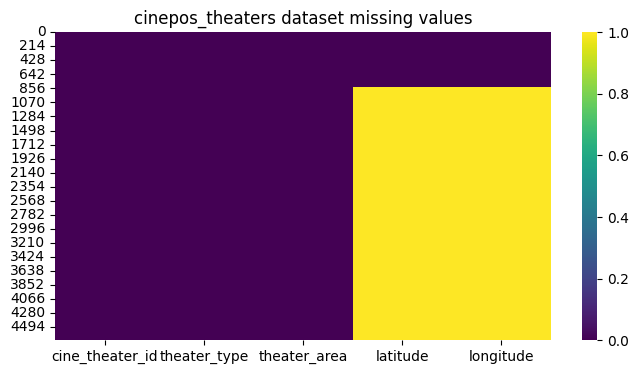

In [98]:
plt.figure(figsize=(8,4))
sns.heatmap(cinepos_theaters.isna(), cmap='viridis')
plt.title("cinepos_theaters dataset missing values")
plt.show()

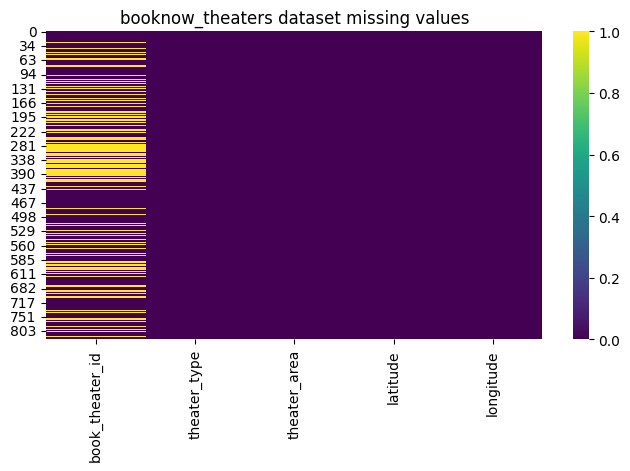

In [99]:
plt.figure(figsize=(8,4))
sns.heatmap(booknow_theaters.isna(), cmap='viridis')
plt.title("booknow_theaters dataset missing values")
plt.show()

### 2.6 DATA SUMMARIZATION

In [100]:
train_data_copy.describe(include='all')

,book_theater_id,show_date,audience_count,day_of_week,is_weekend,month,period
count,214046,214046,214046.000000,214046.000000,214046.000000,214046.000000,214046
unique,826,NaN,NaN,NaN,NaN,NaN,14
top,book_00528,NaN,NaN,NaN,NaN,NaN,2023-12
freq,424,NaN,NaN,NaN,NaN,NaN,21515
mean,NaN,2023-09-13 04:07:24.285807360,41.616568,3.162652,0.461961,6.705012,NaN
min,NaN,2023-01-01 00:00:00,2.000000,0.000000,0.000000,1.000000,NaN
25%,NaN,2023-07-09 00:00:00,18.000000,1.000000,0.000000,2.000000,NaN
50%,NaN,2023-09-25 00:00:00,34.000000,3.000000,0.000000,7.000000,NaN
75%,NaN,2023-12-11 00:00:00,58.000000,5.000000,1.000000,10.000000,NaN
max,NaN,2024-02-28 00:00:00,1350.000000,6.000000,1.000000,12.000000,NaN


In [101]:
test_data_copy.describe(include='all')

,ID,audience_count,book_theater_id,show_date,day_of_week,is_weekend,month,period
count,38062,38062.0,38062,38062,38062.000000,38062.000000,38062.000000,38062
unique,38062,NaN,827,NaN,NaN,NaN,NaN,2
top,book_00001_2024-03-01,NaN,book_00414,NaN,NaN,NaN,NaN,2024-03
freq,1,NaN,53,NaN,NaN,NaN,NaN,22292
mean,NaN,0.0,NaN,2024-03-27 01:00:41.048815104,3.138616,0.476722,3.414324,NaN
min,NaN,0.0,NaN,2024-03-01 00:00:00,0.000000,0.000000,3.000000,NaN
25%,NaN,0.0,NaN,2024-03-14 00:00:00,1.000000,0.000000,3.000000,NaN
50%,NaN,0.0,NaN,2024-03-27 00:00:00,3.000000,0.000000,3.000000,NaN
75%,NaN,0.0,NaN,2024-04-09 00:00:00,5.000000,1.000000,4.000000,NaN
max,NaN,0.0,NaN,2024-04-22 00:00:00,6.000000,1.000000,4.000000,NaN


In [102]:
print(" Descriptive Statistics for Audience_count: \n")

print(f"Minimum: {booknow_visits.audience_count.min()}")
print(f"Maximum: {booknow_visits.audience_count.max()}")
print(f"Average: {booknow_visits.audience_count.mean():.2f}")
print(f"Median: {booknow_visits.audience_count.median():.2f}")
print(f"Standard Deviation: {booknow_visits.audience_count.std():.2f}")
print(f"Variance: {booknow_visits.audience_count.var():.2f}")

 Descriptive Statistics for Audience_count: 

Minimum: 2
Maximum: 1350
Average: 41.62
Median: 34.00
Standard Deviation: 32.84
Variance: 1078.15


### 2.7 Visualization

### 2.7.1 Audience count distribution using Histogram

In [106]:
# ?sns.histplot

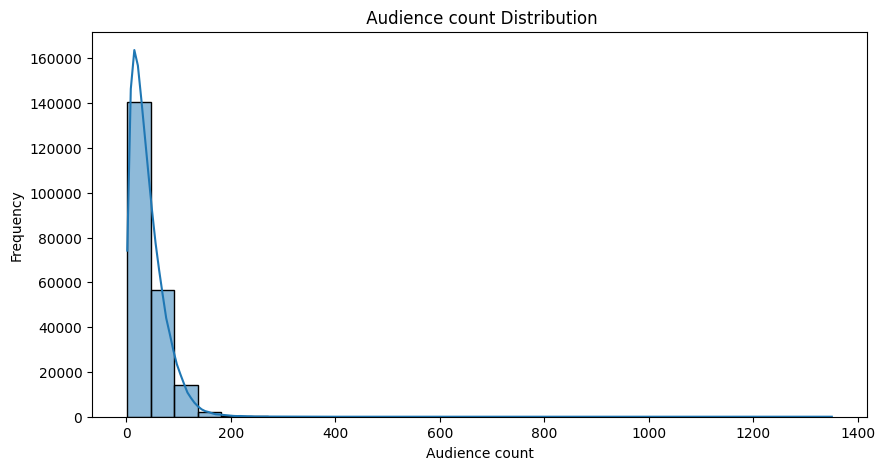

In [107]:
plt.figure(figsize=(10,5))
sns.histplot(train_data_copy['audience_count'], bins=30, kde=True)
plt.title(" Audience count Distribution")
plt.xlabel("Audience count")
plt.ylabel("Frequency")
plt.show()

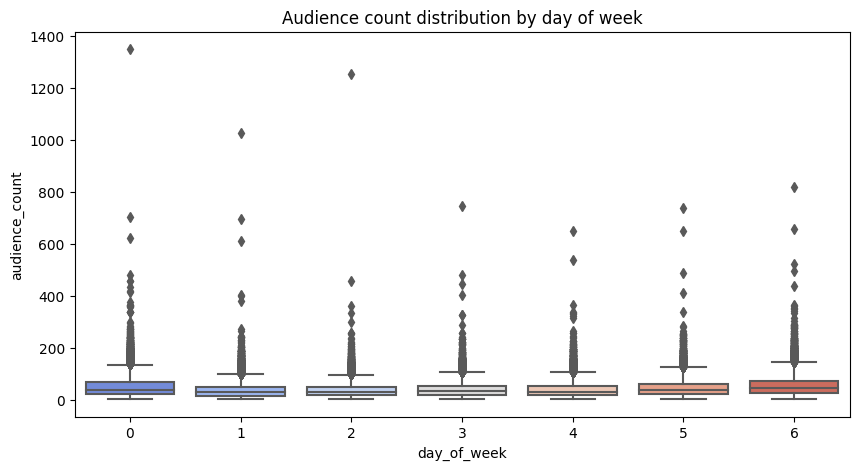

In [108]:
plt.figure(figsize=(10,5))
sns.boxplot(x='day_of_week', y='audience_count', data=train_data_copy, palette='coolwarm')
plt.title("Audience count distribution by day of week")
plt.show()

### 2.7.2 Booknow_booking : Tickets booked distribution

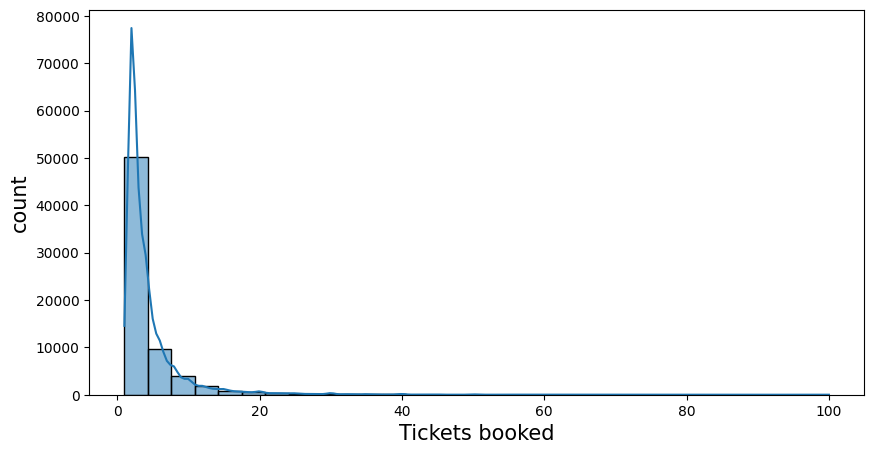

In [109]:
plt.figure(figsize=(10,5))
sns.histplot(booknow_booking1['tickets_booked'], bins=30, kde=True)
plt.xlabel('Tickets booked', fontsize=15)
plt.ylabel("count", fontsize=15)
plt.show()

### 2.7.3 AUDIENCE COUNT PER SHOW_DATE USING LINE PLOT

In [110]:
daily_audience_count=train_data_copy.groupby('show_date')['audience_count'].sum().reset_index()
print(daily_audience_count.shape)
daily_audience_count.head(3)

(424, 2)


,show_date,audience_count
0,2023-01-01,2066
1,2023-01-02,3528
2,2023-01-03,4736


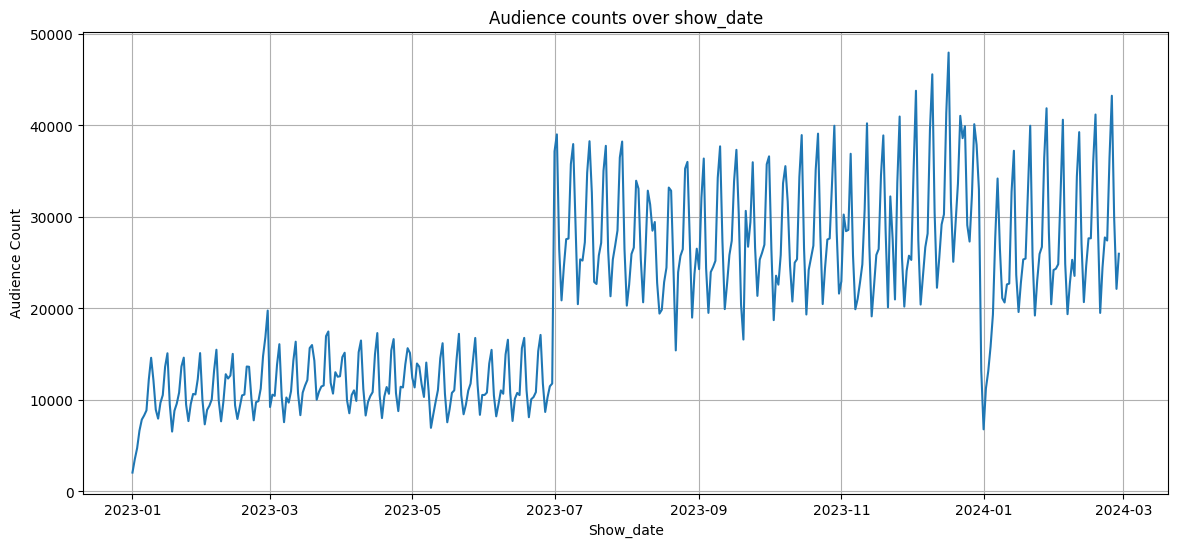

In [111]:
plt.figure(figsize=(14,6))
sns.lineplot(data=daily_audience_count, x='show_date', y='audience_count')
plt.title('Audience counts over show_date')
plt.xlabel('Show_date')
plt.ylabel('Audience Count')
plt.grid(True)
plt.show()

### 2.7.4 Theater information of booknow theaters and CinePOS:

In [112]:
booknow_theaters.theater_type.value_counts()

theater_type
Other     246
Drama     122
Comedy     74
Action     33
Name: count, dtype: int64

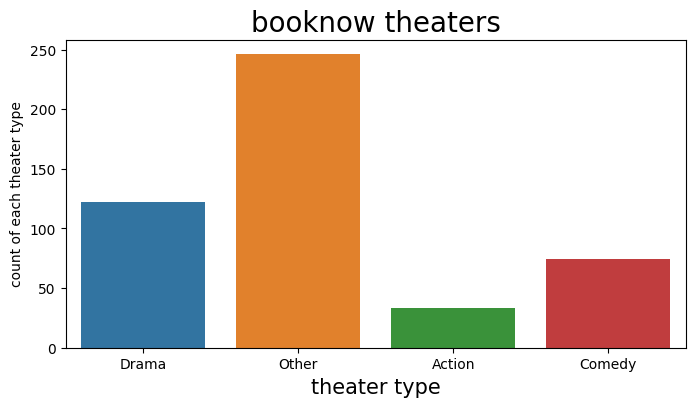

In [113]:
plt.figure(figsize=(8,4))
sns.countplot(data=booknow_theaters, x='theater_type')
plt.xlabel("theater type", fontsize=15)
plt.ylabel("count of each theater type")
plt.title("booknow theaters", fontsize=20)
plt.show()

In [114]:
cinepos_theaters.theater_type.value_counts()

theater_type
Other     3941
Drama      705
Action      44
Name: count, dtype: int64

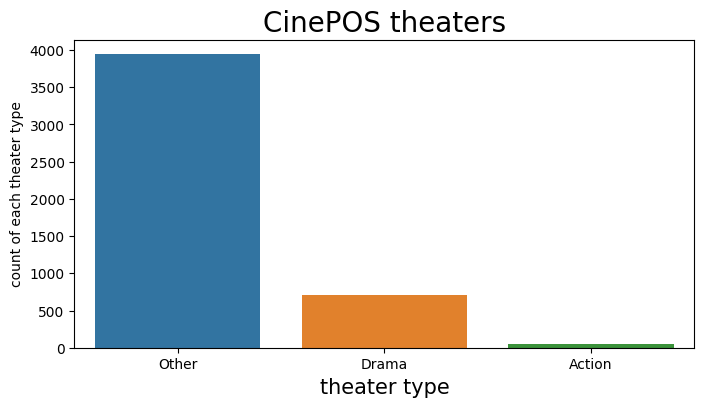

In [115]:
plt.figure(figsize=(8,4))
sns.countplot(data=cinepos_theaters, x='theater_type')
plt.xlabel("theater type", fontsize=15)
plt.ylabel("count of each theater type")
plt.title("CinePOS theaters", fontsize=20)
plt.show()


### 2.7.5 Month-wise Audience count using period ('MM-YYYY')

In [116]:
audience_per_Priod=train_data_copy.groupby('period')['audience_count'].sum().reset_index()
audience_per_Priod

,period,audience_count
0,2023-01,305848
1,2023-02,319868
2,2023-03,378584
3,2023-04,364544
4,2023-05,359236
5,2023-06,351644
6,2023-07,911404
7,2023-08,816600
8,2023-09,829346
9,2023-10,872366


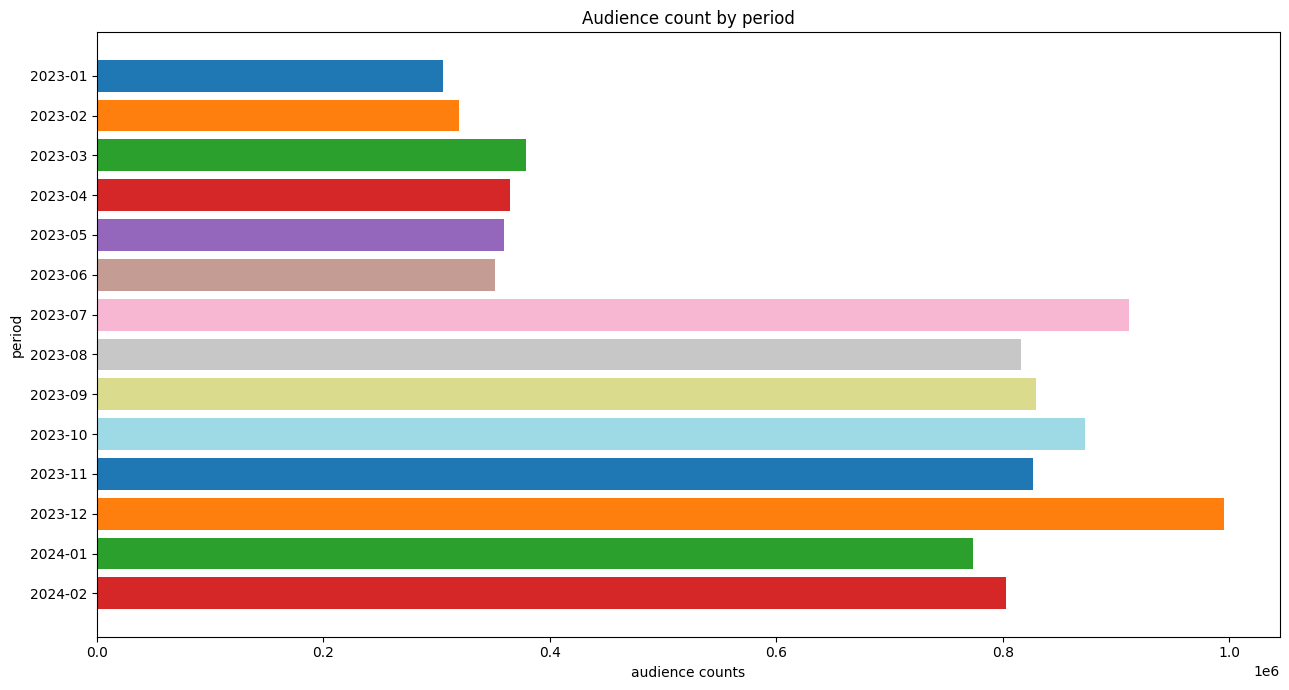

In [119]:
colors=plt.cm.tab20(np.linspace(0,1,10))

plt.figure(figsize=(13,7))
plt.barh(audience_per_Priod['period'].astype(str), audience_per_Priod['audience_count'], color=colors)
plt.ylabel("period")
plt.xlabel("audience counts")
plt.title("Audience count by period")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

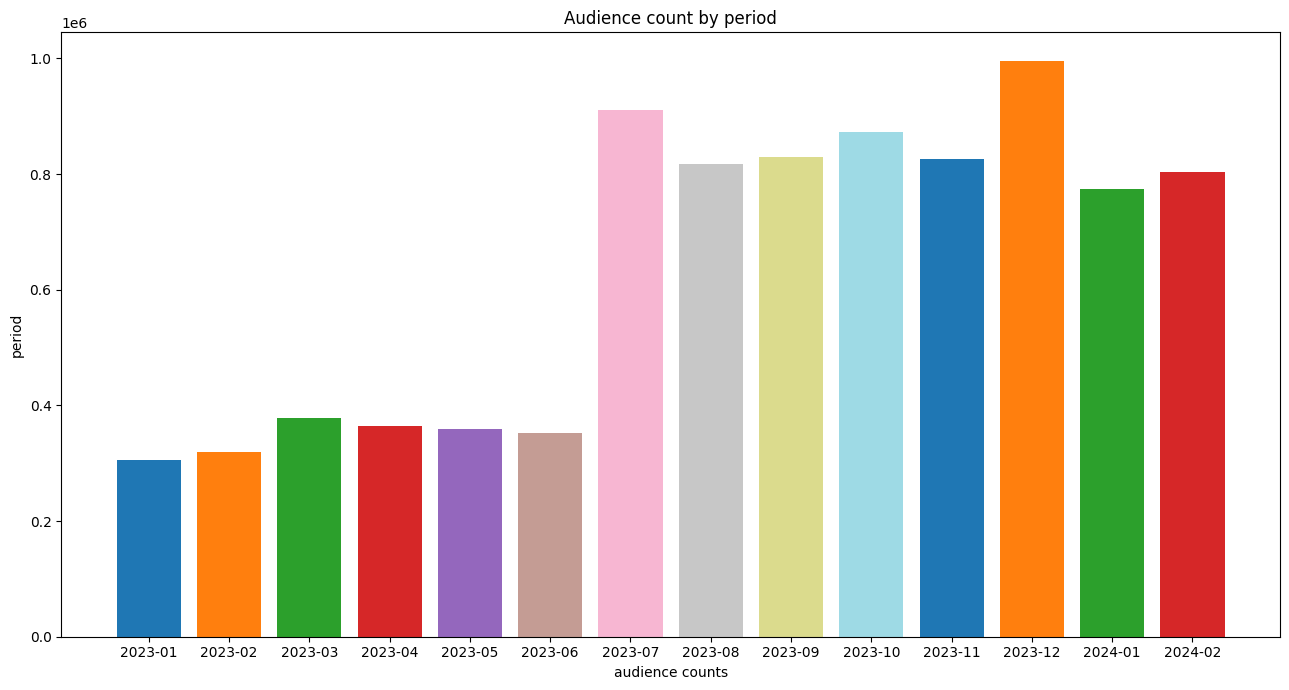

In [120]:
#colors=plt.cm.tab20(np.linspace(0,1,10))

plt.figure(figsize=(13,7))
plt.bar(audience_per_Priod['period'].astype(str), audience_per_Priod['audience_count'], color=colors)
plt.ylabel("period")
plt.xlabel("audience counts")
plt.title("Audience count by period")
#plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


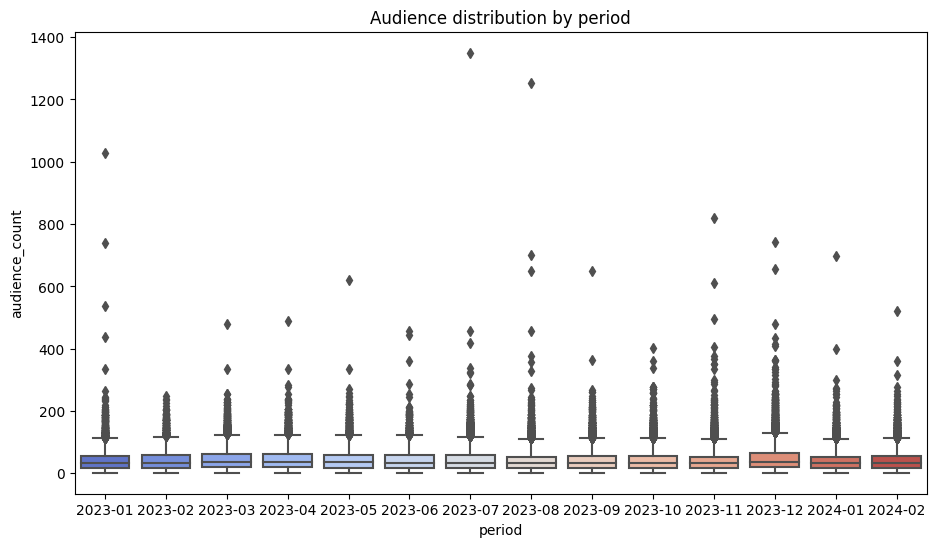

In [121]:
plt.figure(figsize=(11,6))
sns.boxplot(x='period', y='audience_count', data=train_data_copy, palette='coolwarm')
plt.title("Audience distribution by period")
plt.show()

### 2.7.6 Days of week vs Audience count

In [122]:
audience_of_dayofweek=train_data_copy.groupby('day_of_week')['audience_count'].sum().reset_index()
audience_of_dayofweek

,day_of_week,audience_count
0,0,1252736
1,1,955306
2,2,1079726
3,3,1175496
4,4,1201300
5,5,1532668
6,6,1710628


In [123]:
train_data_copy['day_name']=train_data_copy['show_date'].dt.day_name()
train_data_copy['day_name'].value_counts()

day_name
Saturday     33875
Sunday       33079
Friday       31927
Thursday     30940
Wednesday    30656
Tuesday      27264
Monday       26305
Name: count, dtype: int64

In [124]:
audience_of_dayofweek1=train_data_copy.groupby('day_name')['audience_count'].sum().reset_index()
audience_of_dayofweek1

,day_name,audience_count
0,Friday,1201300
1,Monday,1252736
2,Saturday,1532668
3,Sunday,1710628
4,Thursday,1175496
5,Tuesday,955306
6,Wednesday,1079726


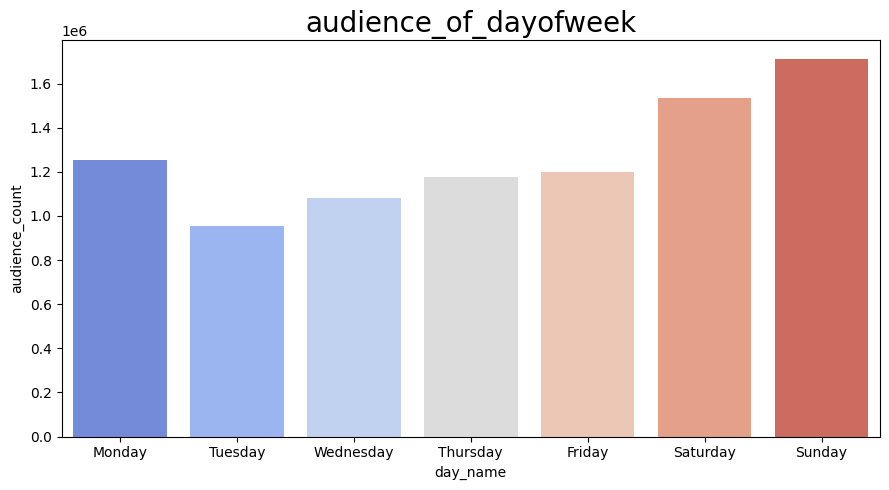

In [125]:
day_order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
audience_of_dayofweek1['day_name']=pd.Categorical(audience_of_dayofweek1['day_name'],categories=day_order, ordered=True)
audience_of_dayofweek1=audience_of_dayofweek1.sort_values(by='day_name')

plt.figure(figsize=(9,5))
sns.barplot(x='day_name', y='audience_count', data=audience_of_dayofweek1, palette='coolwarm')
plt.title("audience_of_dayofweek", fontsize=20)
plt.tight_layout()
plt.show()

### 2.7.7 Weekdays vs Weekend by Audience count

In [126]:
audience_by_weekend=train_data_copy.groupby('is_weekend')['audience_count'].sum().reset_index()
audience_by_weekend

,is_weekend,audience_count
0,0,4463264
1,1,4444596


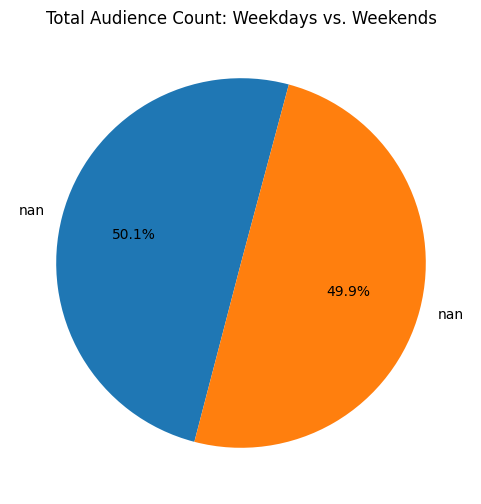

In [128]:
#PIE CHART
audience_by_weekend['is_weekend'] = audience_by_weekend['is_weekend'].map({0: 'Weekday', 1: 'Weekend'})
plt.figure(figsize=(6,6))
plt.pie(audience_by_weekend['audience_count'], labels=audience_by_weekend['is_weekend'],autopct='%1.1f%%',startangle=75)
plt.title('Total Audience Count: Weekdays vs. Weekends')
plt.show()

### Unique Book_theater_id count of Train and Test data

In [129]:
unique_theaters_train = train_data_copy['book_theater_id'].nunique()
unique_theaters_test = test_data_copy['book_theater_id'].nunique()

print(f"unique ID's in training data: {unique_theaters_train}")
print(f"unique ID's in test data: {unique_theaters_test}")

unique ID's in training data: 826
unique ID's in test data: 827


In [130]:
train_data_copy.head()

,book_theater_id,show_date,audience_count,day_of_week,is_weekend,month,period,day_name
0,book_00001,2023-01-13,50,4,1,1,2023-01,Friday
1,book_00001,2023-01-14,64,5,1,1,2023-01,Saturday
2,book_00001,2023-01-15,58,6,1,1,2023-01,Sunday
3,book_00001,2023-01-16,44,0,0,1,2023-01,Monday
4,book_00001,2023-01-18,12,2,0,1,2023-01,Wednesday


### 2.7.8 Unique ID'S count by Period "YYYY-MM"

In [131]:
test_data_copy['period']=test_data_copy['show_date'].dt.to_period('M')

unique_ID_train=train_data_copy.groupby('period')['book_theater_id'].nunique().reset_index()
unique_ID_test=test_data_copy.groupby('period')['book_theater_id'].nunique().reset_index()
unique_ID_test

,period,book_theater_id
0,2024-03,825
1,2024-04,823


In [133]:
unique_ID_train['data_source']='Train'
unique_ID_test['data_source']='Test'
combined_unique_id=pd.concat([unique_ID_train,unique_ID_test])
combined_unique_id

,period,book_theater_id,data_source
0,2023-01,302,Train
1,2023-02,305,Train
2,2023-03,309,Train
3,2023-04,312,Train
4,2023-05,314,Train
5,2023-06,314,Train
6,2023-07,799,Train
7,2023-08,802,Train
8,2023-09,807,Train
9,2023-10,809,Train


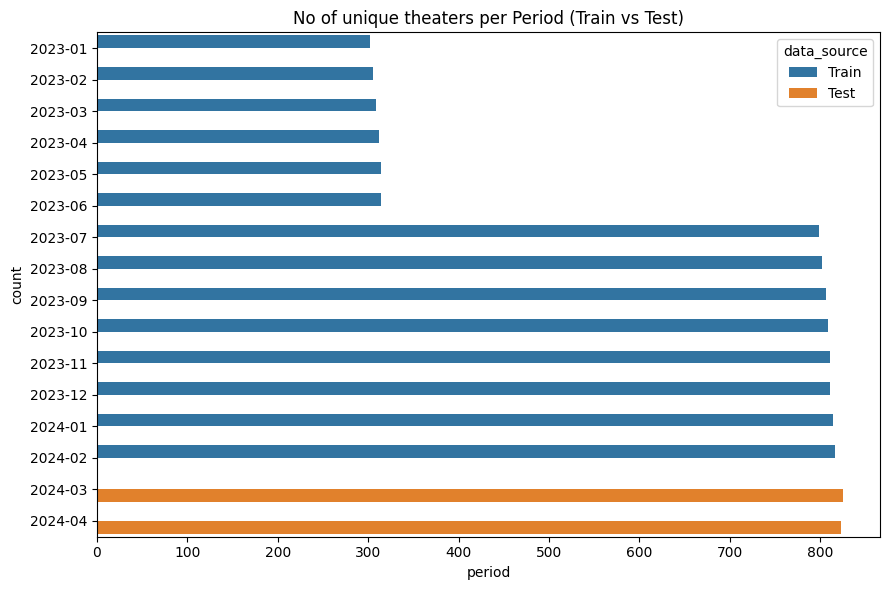

In [134]:
plt.figure(figsize=(9,6))
sns.barplot(x='book_theater_id', y='period', hue='data_source', data=combined_unique_id)
plt.title("No of unique theaters per Period (Train vs Test)")
plt.xlabel("period")
plt.ylabel("count")
plt.tight_layout()
plt.show()

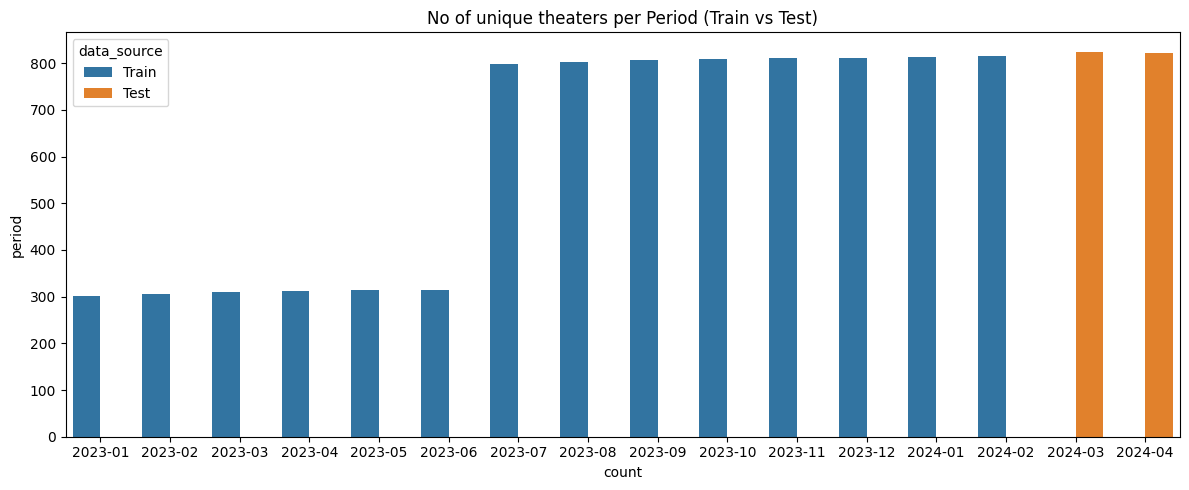

In [135]:
plt.figure(figsize=(12,5))
sns.barplot(x='period', y='book_theater_id', hue='data_source', data=combined_unique_id)
plt.title("No of unique theaters per Period (Train vs Test)")
plt.xlabel("count")
plt.ylabel("period")
plt.tight_layout()
plt.show()

### 2.7.9 COUNT PLOT FOR TOP 10 THEATERS ID FOR AUDIENCE COUNT:

In [136]:
top10_theaters_on_audience_count = booknow_visits.groupby('book_theater_id')['audience_count'].sum().reset_index()
top10_theaters_id=top10_theaters_on_audience_count.sort_values(by='audience_count', ascending=False)[:10]
top10_theaters_id

,book_theater_id,audience_count
115,book_00117,34256
660,book_00664,33066
585,book_00589,32882
699,book_00703,32714
677,book_00681,32226
80,book_00082,31612
524,book_00528,31184
261,book_00263,31174
569,book_00573,31050
205,book_00207,30782


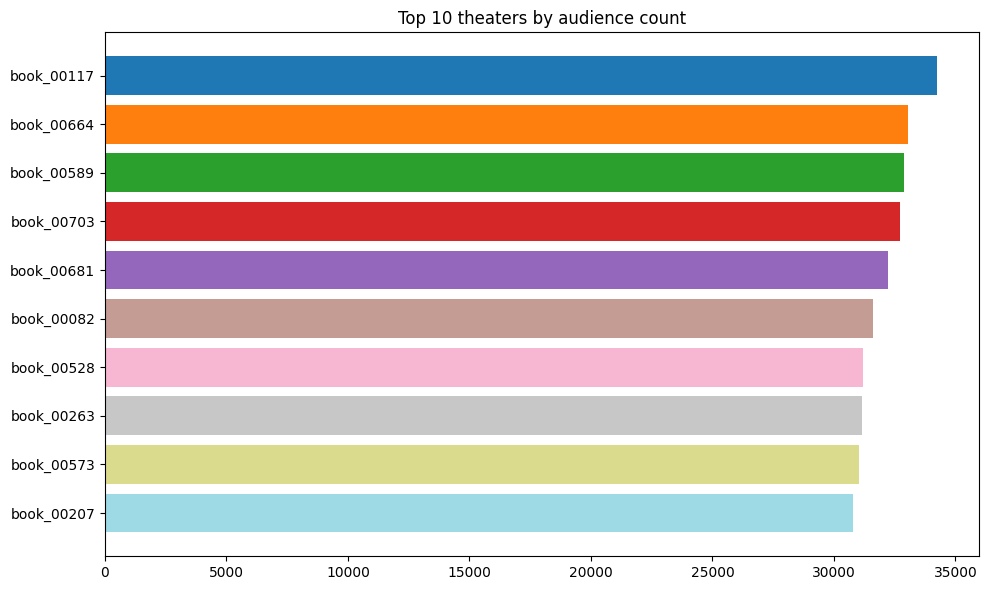

In [137]:
colors=plt.cm.tab20(np.linspace(0,1,10))

plt.figure(figsize=(10,6))
plt.barh(top10_theaters_id['book_theater_id'].astype(str), top10_theaters_id['audience_count'], color=colors)
plt.title("Top 10 theaters by audience count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 2.7.10 COMPARING AUDIENCE COUNT VS TICKETS BOOKED

In [138]:
booknow_booking1['show_datetime'] = pd.to_datetime(booknow_booking['show_datetime'])
booknow_booking1['show_date'] = booknow_booking1['show_datetime'].dt.date
booknow_booking1['period'] = pd.to_datetime(booknow_booking1['show_date']).dt.to_period('M')

daily_tickets_booked = (booknow_booking1.groupby(['period'])['tickets_booked'].sum().reset_index())
print(daily_tickets_booked.head())
print(audience_per_Priod.head())

    period  tickets_booked
0  2023-01           10175
1  2023-02           11426
2  2023-03           16820
3  2023-04           13544
4  2023-05            8188
    period  audience_count
0  2023-01          305848
1  2023-02          319868
2  2023-03          378584
3  2023-04          364544
4  2023-05          359236


In [139]:
merged_period_data = pd.merge(audience_per_Priod, daily_tickets_booked, on='period', how='inner')
merged_period_data

,period,audience_count,tickets_booked
0,2023-01,305848,10175
1,2023-02,319868,11426
2,2023-03,378584,16820
3,2023-04,364544,13544
4,2023-05,359236,8188
5,2023-06,351644,4411
6,2023-07,911404,4460
7,2023-08,816600,2
8,2023-09,829346,12
9,2023-10,872366,7709


In [140]:
melted_data = merged_period_data.melt(id_vars='period', var_name='Metric', value_name='Count')
melted_data

,period,Metric,Count
0,2023-01,audience_count,305848
1,2023-02,audience_count,319868
2,2023-03,audience_count,378584
3,2023-04,audience_count,364544
4,2023-05,audience_count,359236
5,2023-06,audience_count,351644
6,2023-07,audience_count,911404
7,2023-08,audience_count,816600
8,2023-09,audience_count,829346
9,2023-10,audience_count,872366


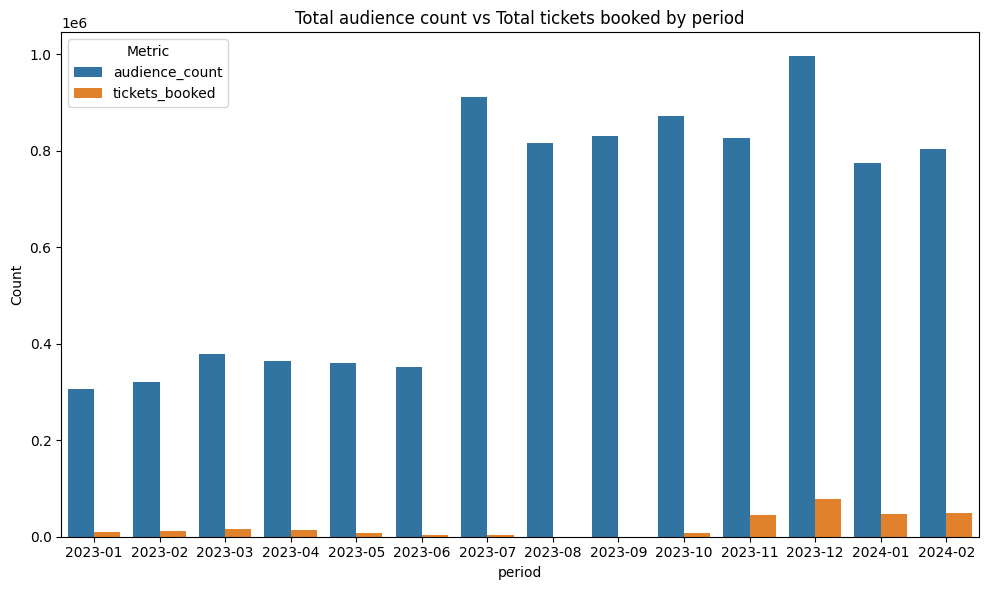

In [141]:
plt.figure(figsize=(10,6))
sns.barplot(x='period', y='Count', hue='Metric', data=melted_data)
plt.title("Total audience count vs Total tickets booked by period")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

# 3. PROJECT DATA ANALYSIS BEGINS...

In [142]:
sample_submission['book_theater_id'] = sample_submission['ID'].str[:10]
sample_submission['show_date'] = sample_submission['ID'].str[-10:]
sample_submission['show_date'] = pd.to_datetime(sample_submission['show_date'])

test_data = sample_submission.copy()   #TEST DATA FOR FINAL PREDICTION
train_data = booknow_visits.copy()

print(f"Training data: {train_data.shape}")
print(f"Test data: {test_data.shape}")

Training data: (214036, 3)
Test data: (38062, 4)


## 3.1 DATE FEATURES EXTRACTION..

In [143]:
def simple_date_features(df):

    df = df.copy()
    df['show_date'] = pd.to_datetime(df['show_date'])
    
    df['day_of_week'] = df['show_date'].dt.dayofweek  # Monday=0, Sunday=6
    df['is_weekend'] = (df['day_of_week'] >= 4).astype(int)  # 1 if Saturday or Sunday
    df['day_of_month'] = df['show_date'].dt.day
    df['month'] = df['show_date'].dt.month
    df['period'] = df['show_date'].dt.to_period('M')
    df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    #df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    #df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    #df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    
    return df

train_data = simple_date_features(train_data)
test_data = simple_date_features(test_data)

print(train_data.shape)
print(test_data.shape)

(214036, 9)
(38062, 10)


In [84]:
# Q1 = train_data['audience_count'].quantile(0.25)
# Q3 = train_data['audience_count'].quantile(0.75)
# IQR = Q3 - Q1

# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR

# outliers = train_data[(train_data['audience_count'] < lower_bound) | (train_data['audience_count'] > upper_bound)]

# print(f"Number of outliers detected: {len(outliers)}")
# print(outliers.shape)
# print(outliers.head(2))

Number of outliers detected: 5589
(5589, 9)
    book_theater_id  show_date  audience_count  day_of_week  is_weekend  \
140      book_00001 2023-07-01             122            5           1   
639      book_00003 2023-07-10             132            0           0   

     day_of_month  month   period  day_of_week_cos  
140             1      7  2023-07        -0.222521  
639            10      7  2023-07         1.000000  


In [85]:
# train_data=train_data[~((train_data['audience_count'] < lower_bound) | (train_data['audience_count'] > upper_bound))]
# print(train_data.shape)
# print(test_data.shape)

(208457, 9)
(38062, 10)


In [144]:
print(train_data.book_theater_id.nunique())
print(test_data.book_theater_id.nunique())
print(theater_relation.book_theater_id.nunique())
print(theater_relation.cine_theater_id.nunique()) 

826
827
150
150


## 3.2 Computing mean, median, std of Audience count by Book_theater_Id

In [145]:
def simple_bookid_features(df, book_data):

    book_data['show_date'] = pd.to_datetime(book_data['show_date'])
    
    theater_info = book_data.groupby('book_theater_id').agg(
        {'audience_count': ['mean', 'median','std','var','sum']}).reset_index()
    
    theater_info.columns = ['book_theater_id', 'book_thr_avg_audience', 'book_thr_median_audience','book_thr_std_audience','book_thr_var_audience',
                           'book_thr_total_audience']
    
    df = df.merge(theater_info, on='book_theater_id', how='left')
    df['book_thr_avg_audience']=df['book_thr_avg_audience'].fillna(df['book_thr_avg_audience'].mean())
    df['book_thr_median_audience']=df['book_thr_median_audience'].fillna(df['book_thr_median_audience'].mean())
    df['book_thr_std_audience']=df['book_thr_std_audience'].fillna(df['book_thr_std_audience'].mean())
    df['book_thr_var_audience']=df['book_thr_var_audience'].fillna(df['book_thr_var_audience'].mean())
    df['book_thr_total_audience']=df['book_thr_total_audience'].fillna(df['book_thr_total_audience'].mean())
    
    return df


train_data = simple_bookid_features(train_data, booknow_visits)
test_data = simple_bookid_features(test_data, booknow_visits)
print(train_data.shape)
print(test_data.shape)

(214036, 14)
(38062, 15)


## 3.3 Compute average audience count per (day_of_month, month) #ALL 365 DAYS

In [146]:
train_data_df=train_data.sort_values(by='show_date', ascending=True)
train_data_df['show_date'] = pd.to_datetime(train_data_df['show_date'])

start_date = '2023-01-01'
end_date = '2023-12-31'

filtered_df = train_data_df[(train_data_df['show_date'] >= start_date) &(train_data_df['show_date'] <= end_date)]

train_data_df = filtered_df.copy()

In [147]:
train_data_df.head(2)

,book_theater_id,show_date,audience_count,day_of_week,is_weekend,day_of_month,month,period,day_of_week_cos,book_thr_avg_audience,book_thr_median_audience,book_thr_std_audience,book_thr_var_audience,book_thr_total_audience
35573,book_00140,2023-01-01,22,6,1,1,1,2023-01,0.62349,20.720588,20.0,10.352052,107.164980,8454
32286,book_00128,2023-01-01,124,6,1,1,1,2023-01,0.62349,42.177474,32.0,43.152119,1862.105381,12358


In [148]:
avg_audience = (train_data_df.groupby(['day_of_month', 'month'])['audience_count']
    .agg(show_dt_avg_audience='mean',show_dt_median_audience='median',show_dt_std_audience='std').reset_index())
avg_audience

,day_of_month,month,show_dt_avg_audience,show_dt_median_audience,show_dt_std_audience
0,1,1,43.041667,28.0,43.693302
1,1,2,31.904348,26.0,24.640817
2,1,3,34.576779,26.0,26.831917
3,1,4,49.608108,42.0,43.209954
4,1,5,55.677130,44.0,56.509616
...,...,...,...,...,...
360,31,5,37.272085,32.0,26.478283
361,31,7,44.534454,36.0,38.093851
362,31,8,37.159664,30.0,27.868852
363,31,10,33.425039,26.0,27.007685


In [149]:
#avg_audience = (train_data_df.groupby(['day_of_month', 'month'])['audience_count']

train_data = pd.merge(train_data, avg_audience, on=['day_of_month','month'], how='left')
test_data =  pd.merge(test_data, avg_audience, on=['day_of_month','month'], how='left')

print(avg_audience.shape)
print(train_data.shape)
print(test_data.shape)

(365, 5)
(214036, 17)
(38062, 18)


In [91]:
# filtered_df.head(2)

In [129]:
# unique_audience_per_period = train_data_df.groupby(['month'])['audience_count'].sum().reset_index()
# # print("Unique audience count per month-year period:")
# # unique_audience_per_period=pd.DataFrame(unique_audience_per_period)
# unique_audience_per_period

In [92]:
# unique_audience_per_period['normalized_audi_count']=unique_audience_per_period['audience_count']/unique_audience_per_period['audience_count'].max()
# period_audience_data=unique_audience_per_period[['month','normalized_audi_count']]
# period_audience_data

In [27]:
# train_data = pd.merge(train_data, period_audience_data, on=['month'], how='left')
# test_data =  pd.merge(test_data, period_audience_data, on=['month'], how='left')

# print(avg_audience.shape)
# print(train_data.shape)
# print(test_data.shape)

(12, 3)
(214046, 15)
(38062, 16)


## 3.4 Day of week of Audience count

In [30]:
# scaled_count_weekly=train_data_copy.groupby('day_of_week')['audience_count'].agg(dayofwk_avg='mean',dayofwk_median='median',dayofwk_total='sum').reset_index()  

# train_data = pd.merge(train_data, scaled_count_weekly, on=['day_of_week'], how='left')
# test_data =  pd.merge(test_data, scaled_count_weekly, on=['day_of_week'], how='left')

# print(scaled_count_weekly.shape)
# print(train_data.shape)
# print(test_data.shape)

(7, 3)
(214046, 17)
(38062, 18)


In [ ]:
# train_data=pd.merge(train_data, scaled_count_weekly1, on='day_of_week', how='left')
# test_data=pd.merge(test_data, scaled_count_weekly1, on='day_of_week', how='left')

# print(train_data.shape)
# print(test_data.shape)
# train_data.head(3)

In [130]:
train_data.head()

,book_theater_id,show_date,audience_count,day_of_week,is_weekend,day_of_month,month,period,day_of_week_cos,book_thr_avg_audience,book_thr_median_audience,book_thr_std_audience,book_thr_var_audience,book_thr_total_audience,show_dt_avg_audience,show_dt_median_audience,show_dt_std_audience
0,book_00001,2023-01-13,50,4,1,13,1,2023-01,-0.900969,47.05848,46.0,23.388397,547.017098,16094,36.866920,30.0,41.960102
1,book_00001,2023-01-14,64,5,1,14,1,2023-01,-0.222521,47.05848,46.0,23.388397,547.017098,16094,38.459854,30.0,49.964752
2,book_00001,2023-01-15,58,6,1,15,1,2023-01,0.623490,47.05848,46.0,23.388397,547.017098,16094,47.013793,40.0,34.819254
3,book_00001,2023-01-16,44,0,0,16,1,2023-01,1.000000,47.05848,46.0,23.388397,547.017098,16094,53.560284,48.0,34.511408
4,book_00001,2023-01-18,12,2,0,18,1,2023-01,-0.222521,47.05848,46.0,23.388397,547.017098,16094,28.973451,23.0,23.915578


## 3.5 Unique theater id's on period:

In [12]:
# test_data_copy['period'] = test_data_copy['show_date'].dt.to_period('M')

# unique_theaters_per_period = train_data_copy.groupby('month')['book_theater_id'].nunique().reset_index()
# unique_id_train_data=unique_theaters_per_period[['month','book_theater_id']]
# unique_id_train_data.columns=['month','book_id_monthly_count']
# unique_id_train_data

In [ ]:
# train_data=pd.merge(train_data, unique_id_train_data, on='month', how='left')
# test_data=pd.merge(test_data, unique_id_train_data, on='month', how='left')

# print(train_data.shape)
# print(test_data.shape)
# train_data.head(3)

## 3.6 Tickets bookd count on Book id's

In [131]:
booknow_booking['show_datetime']=pd.to_datetime(booknow_booking['show_datetime'])
booknow_booking['show_date']=booknow_booking['show_datetime'].dt.date
booknow_booking['day_of_month']=pd.to_datetime(booknow_booking['show_date']).dt.day
booknow_booking['month']=pd.to_datetime(booknow_booking['show_date']).dt.month

In [150]:
def simple_booking_features(df, booking_data):

    daily_bookings = booking_data.groupby(['book_theater_id'])['tickets_booked'].sum().reset_index()
    
    daily_bookings.columns = ['book_theater_id','booking_tickets_sum']

    df = df.merge(daily_bookings, on=['book_theater_id'], how='left')

    #df['booking_tickets_count']=df['booking_tickets_count'].fillna(df['booking_tickets_count'].mean())
    df['booking_tickets_sum']=df['booking_tickets_sum'].fillna(df['booking_tickets_sum'].mean())
    
    return df

train_data = simple_booking_features(train_data, booknow_booking)
test_data = simple_booking_features(test_data, booknow_booking)

print(train_data.shape)
print(test_data.shape)


(214036, 18)
(38062, 19)


In [ ]:
# def create_simple_booking_features(df, booking_data):

#     #df = df.copy()
#     #booking_data = booking_data.copy()

#     daily_bookings = booking_data.groupby(['book_theater_id']).agg(
#         {'booking_datetime': 'count', 'tickets_booked': 'sum'}).reset_index()

#     daily_bookings.columns = ['book_theater_id','booking_tickets_count','booking_tickets_sum']

#     df = df.merge(daily_bookings, on=['book_theater_id'], how='left')

#     df['booking_tickets_count']=df['booking_tickets_count'].fillna(df['booking_tickets_count'].mean())
#     df['booking_tickets_sum']=df['booking_tickets_sum'].fillna(df['booking_tickets_sum'].mean())
    
#     return df

# train_data = create_simple_booking_features(train_data, booknow_booking)
# test_data = create_simple_booking_features(test_data, booknow_booking)

# print(train_data.shape)
# print(test_data.shape)


In [35]:
# cinepos_booking['show_datetime']=pd.to_datetime(cinepos_booking['show_datetime'])
# cinepos_booking['show_date']=cinepos_booking['show_datetime'].dt.date
# cinepos_booking['month']=pd.to_datetime(cinepos_booking['show_date']).dt.month

# cinepos_df=cinepos_booking.sort_values(by='show_date', ascending=True)
# cinepos_df['show_date'] = pd.to_datetime(cinepos_df['show_date'])

# start_date = '2023-01-01'
# end_date = '2023-12-31'

# cinepos_df = cinepos_df[(cinepos_df['show_date'] >= start_date) &(cinepos_df['show_date'] <= end_date)]
# cinepos_df.head(2)

,cine_theater_id,show_datetime,booking_datetime,tickets_sold,show_date,month
0,cinePOS_00001,2023-01-01 11:00:00,2023-01-01 09:00:00,1,2023-01-01,1
97,cinePOS_00087,2023-01-01 19:00:00,2023-01-01 10:00:00,2,2023-01-01,1


In [133]:
# monthly_ticketsold=cinepos_df.groupby('month')['tickets_sold'].mean().reset_index()
# monthly_ticketsold1=monthly_ticketsold[:12]
# monthly_ticketsold1

In [38]:
# train_data = pd.merge(train_data,monthly_ticketsold1, on=['month'], how='left')
# test_data = pd.merge(test_data,monthly_ticketsold1, on=['month'], how='left')

# print(train_data.shape)
# print(test_data.shape)

(214046, 19)
(38062, 20)


In [ ]:
# #cinepos tickets sold
# def cinepos_ticketsold_features(df, cinepos_data):

#     #df = df.copy()
#     #booking_data = booking_data.copy()

#     daily_ticket_sold = cinepos_data.groupby(['book_theater_id']).['tickets_sold'].sum().reset_index()

#     daily_ticket_sold.columns = ['book_theater_id','cinepos_tickets_sold']

#     df = df.merge(daily_ticket_sold, on=['book_theater_id'], how='left')

#     df['booking_tickets_count']=df['booking_tickets_count'].fillna(df['booking_tickets_count'].mean())
#     df['booking_tickets_sum']=df['booking_tickets_sum'].fillna(df['booking_tickets_sum'].mean())
    
#     return df

# train_data = cinepos_ticketsold_features(train_data, cinepos_booking)
# test_data = cinepos_ticketsold_features(test_data, cinepos_booking)

# print(train_data.shape)
# print(test_data.shape)

### 3.6.1 Pairplot
* all in one single grid of scatterplots and histograms. It plots every numerical column against every other numerical column to show how they relate.

In [134]:
train_data.columns

Index(['book_theater_id', 'show_date', 'audience_count', 'day_of_week',
       'is_weekend', 'day_of_month', 'month', 'period', 'day_of_week_cos',
       'book_thr_avg_audience', 'book_thr_median_audience',
       'book_thr_std_audience', 'book_thr_var_audience',
       'book_thr_total_audience', 'show_dt_avg_audience',
       'show_dt_median_audience', 'show_dt_std_audience',
       'booking_tickets_sum'],
      dtype='object')

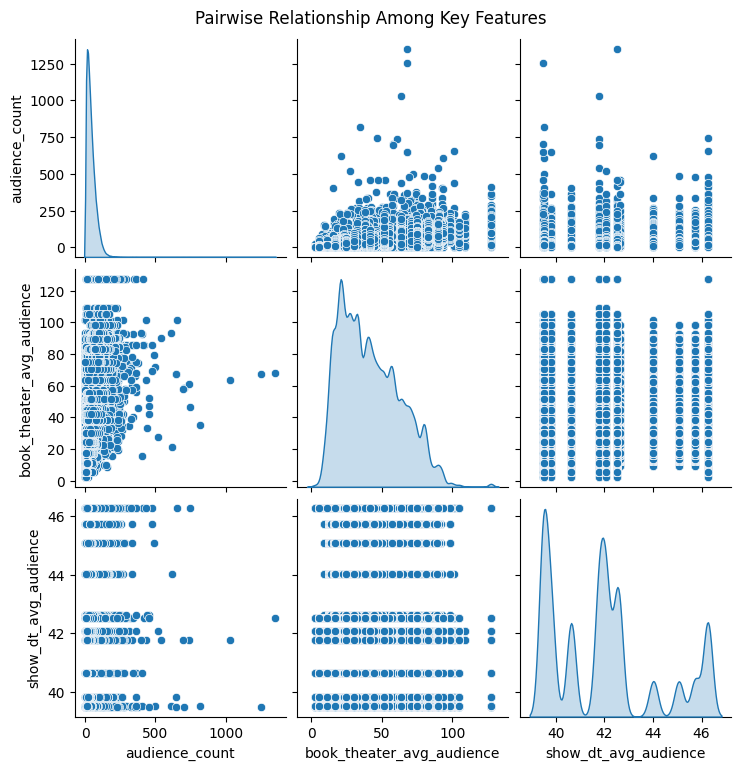

In [39]:
sns.pairplot(train_data[['audience_count','book_theater_avg_audience','show_dt_avg_audience']], diag_kind='kde')
plt.suptitle('Pairwise Relationship Among Key Features', y=1.02)
plt.show()

In [151]:
print(train_data.isna().sum().sum())
print(test_data.isna().sum().sum())

0
0


## 3.7 ENCODING FOR THEATER TYPES

In [155]:
print(booknow_theaters.shape)
theater_data=booknow_theaters.theater_type
#theater_data.head(2)
booknow_theaters.theater_type.value_counts()

(475, 5)


theater_type
Other     246
Drama     122
Comedy     74
Action     33
Name: count, dtype: int64

In [158]:
theater_encode = LabelEncoder()

theater_data_encoded = theater_encode.fit_transform(theater_data)
theater_data_encoded=pd.DataFrame(theater_data_encoded, columns=['theater_type'])
theater_data_encoded.value_counts()

theater_type
3               246
2               122
1                74
0                33
Name: count, dtype: int64

## 3.8 Cinepos theater tickets sold info

In [159]:
#CINE POS THEATER
print(cinepos_theaters.shape)
print(cinepos_theaters.cine_theater_id.nunique())
print(cinepos_booking.cine_theater_id.nunique())
cinepos_booking.columns

(4690, 5)
4690
13161


Index(['cine_theater_id', 'show_datetime', 'booking_datetime', 'tickets_sold'], dtype='object')

In [ ]:
# cinepos_booking['show_datetime']=pd.to_datetime(cinepos_booking['show_datetime'])
# cinepos_booking['show_date']=cinepos_booking['show_datetime'].dt.date
# cinepos_booking['day_of_month']=pd.to_datetime(cinepos_booking['show_date']).dt.day
# cinepos_booking['month']=pd.to_datetime(cinepos_booking['show_date']).dt.month

# def cinepos_features(df, cinepos_data):

#     daily_cinepos_bookings = cinepos_data.groupby(['day_of_month','month']).agg(
#         {'booking_datetime': 'count', 'tickets_sold': 'sum'}).reset_index()

#     daily_cinepos_bookings.columns = ['day_of_month','month','cinepos_tickets_count','cinepos_tickets_sum']

#     df = df.merge(daily_cinepos_bookings, on=['day_of_month','month'], how='left')

#     df['cinepos_tickets_count']=df['cinepos_tickets_count'].fillna(df['cinepos_tickets_count'].mean())
#     df['cinepos_tickets_sum']=df['cinepos_tickets_sum'].fillna(df['cinepos_tickets_sum'].mean())
    
#     return df

# train_data = cinepos_features(train_data, cinepos_booking)
# test_data = cinepos_features(test_data, cinepos_booking)

# print(train_data.shape)
# print(test_data.shape)


In [ ]:
# train_missing_cols = train_data.columns[train_data.isna().any()].tolist()

# # Identify columns with missing values in test_data
# test_missing_cols = test_data.columns[test_data.isna().any()].tolist()

# # Combine unique missing columns from both dataframes
# all_missing_cols = list(set(train_missing_cols + test_missing_cols))

# # Fill missing values with the mean for each of these columns
# for col in all_missing_cols:
#     if col in train_data.columns:
#         train_data[col] = train_data[col].fillna(train_data[col].mean())
#     if col in test_data.columns:
#         test_data[col] = test_data[col].fillna(train_data[col].mean())

# #train_data[col].mean()

## 3.9 Lag and Rolling mean features

* lag_1	- Yesterday’s audience - Captures immediate short-term memory
* lag_7 - Audience a week ago - Captures weekly pattern
* rolling_mean_7 - 7-day moving average - Smooths fluctuations to show trend
* rolling_std_7	- 7-day moving volatility - Captures how variable audience is

In [ ]:
# train_data['rolling_mean_7'] = train_data['audience_count'].rolling(window=1).mean()
# train_data['rolling_std_7'] = train_data['audience_count'].rolling(window=7).mean()

# test_data['rolling_mean_7'] = test_data['audience_count'].rolling(window=1).mean()
# test_data['rolling_std_7'] = test_data['audience_count'].rolling(window=7).mean()

# train_data['rolling_std_7']=train_data['rolling_std_7'].fillna(0)
# test_data['rolling_std_7']=test_data['rolling_std_7'].fillna(0)

In [47]:
# train_data = train_data.sort_values('show_date')
# test_data = test_data.sort_values('show_date')

# # train_data['lag_1'] = train_data['audience_count'].shift(1)
# # train_data['lag_7'] = train_data['audience_count'].shift(7)

# # test_data['lag_1'] = test_data['audience_count'].shift(1)
# # test_data['lag_7'] = test_data['audience_count'].shift(7)

# train_data['rolling_mean_3'] = train_data['audience_count'].shift(1).rolling(window=3).mean()
# train_data['rolling_std_3']  = train_data['audience_count'].shift(1).rolling(window=3).std()

# test_data['rolling_mean_3'] = test_data['audience_count'].shift(1).rolling(window=3).mean()
# test_data['rolling_std_3']  = test_data['audience_count'].shift(1).rolling(window=3).std()

# for col in ['rolling_mean_3','rolling_std_3']:  #'lag_1','lag_7',
#     train_data[col] = train_data[col].fillna(method='bfill')
#     test_data[col]  = test_data[col].fillna(method='bfill')

# print(train_data.shape)
# print(test_data.shape)

(214046, 22)
(38062, 24)


## 3.10 Train and validation splits for time series manually set the date range

In [160]:
train_data1 = train_data.sort_values('show_date')

train = train_data1[~((train_data1['show_date'] >= '2023-03-01') & (train_data1['show_date'] <= '2023-04-30'))]
valid = train_data1[(train_data1['show_date'] >= '2023-03-01') & (train_data1['show_date'] <= '2023-04-30')]

print("Train shape:", train.shape)
print("Validation shape:", valid.shape)

Train shape: (197669, 18)
Validation shape: (16367, 18)


In [ ]:
# train_data1 = train_data.sort_values('show_date')
# train = train_data1[~((train_data1['show_date'] >= '2024-01-01') & (train_data1['show_date'] <= '2024-02-28'))]
# valid = train_data1[((train_data1['show_date'] >= '2024-01-01') & (train_data1['show_date'] <= '2024-02-28'))]

# print("Train shape:", train.shape)
# print("Validation shape:", valid.shape)

## 3.11 HEATMAP - CORRELATION MAP

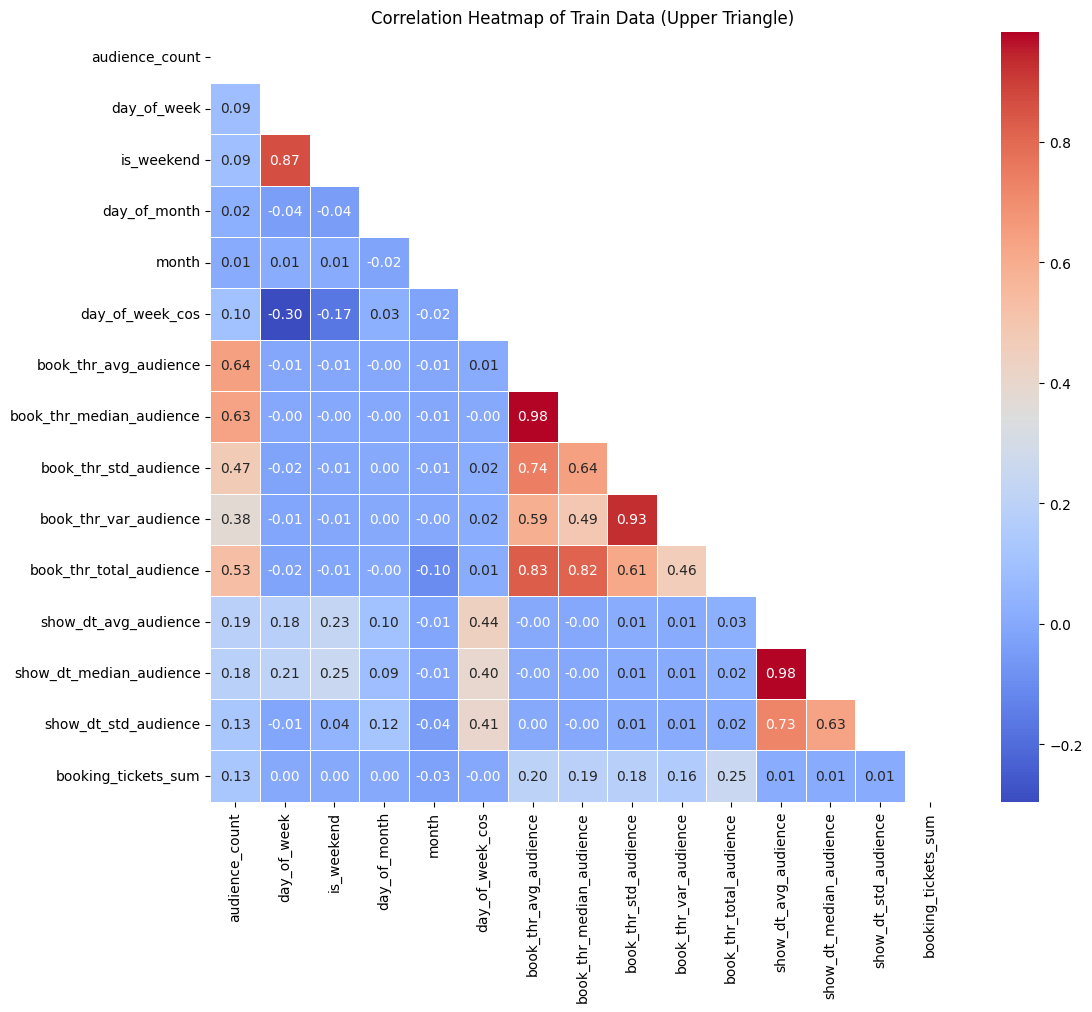

In [161]:
import matplotlib.pyplot as plt
import seaborn as sns
#new_mat=pd.concat([X_train, y_train], axis=1)
corr_matrix = train_data.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title('Correlation Heatmap of Train Data (Upper Triangle)')
plt.show()

In [162]:
train.columns

Index(['book_theater_id', 'show_date', 'audience_count', 'day_of_week',
       'is_weekend', 'day_of_month', 'month', 'period', 'day_of_week_cos',
       'book_thr_avg_audience', 'book_thr_median_audience',
       'book_thr_std_audience', 'book_thr_var_audience',
       'book_thr_total_audience', 'show_dt_avg_audience',
       'show_dt_median_audience', 'show_dt_std_audience',
       'booking_tickets_sum'],
      dtype='object')

In [58]:
test_data_cleaned.columns

Index(['day_of_week', 'is_weekend', 'book_theater_avg_audience',
       'book_theater_median_audience', 'book_theater_std_audience',
       'book_theater_var_audience', 'show_dt_avg_audience',
       'show_dt_median_audience', 'normalized_audi_count', 'dayofwk_avg',
       'dayofwk_total', 'booking_tickets_sum', 'tickets_sold'],
      dtype='object')

In [57]:
X_train.columns

Index(['day_of_week', 'is_weekend', 'book_theater_avg_audience',
       'book_theater_median_audience', 'book_theater_std_audience',
       'book_theater_var_audience', 'show_dt_avg_audience',
       'show_dt_median_audience', 'normalized_audi_count', 'dayofwk_avg',
       'dayofwk_total', 'booking_tickets_sum', 'tickets_sold'],
      dtype='object')

## 3.12 Redundant Features removing

In [163]:
X_train=train.drop(columns=['book_theater_id','show_date','audience_count','day_of_month', 'month','period','show_dt_std_audience','booking_tickets_sum'], axis=1)
y_train=train['audience_count']
X_test=valid.drop(columns=['book_theater_id','show_date','audience_count','day_of_month', 'month','period','show_dt_std_audience','booking_tickets_sum'], axis=1)
y_test=valid['audience_count']
test_data_cleaned=test_data.drop(columns=['ID','book_theater_id','show_date','audience_count','day_of_month', 'month','period','show_dt_std_audience','booking_tickets_sum'], axis=1)

In [164]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
print(test_data_cleaned.shape)

(197669, 10)
(16367, 10)
(197669,)
(16367,)
(38062, 10)


## 3.12.1 INPUT FEATURES CORRELATION WITH TARGET FEATURES

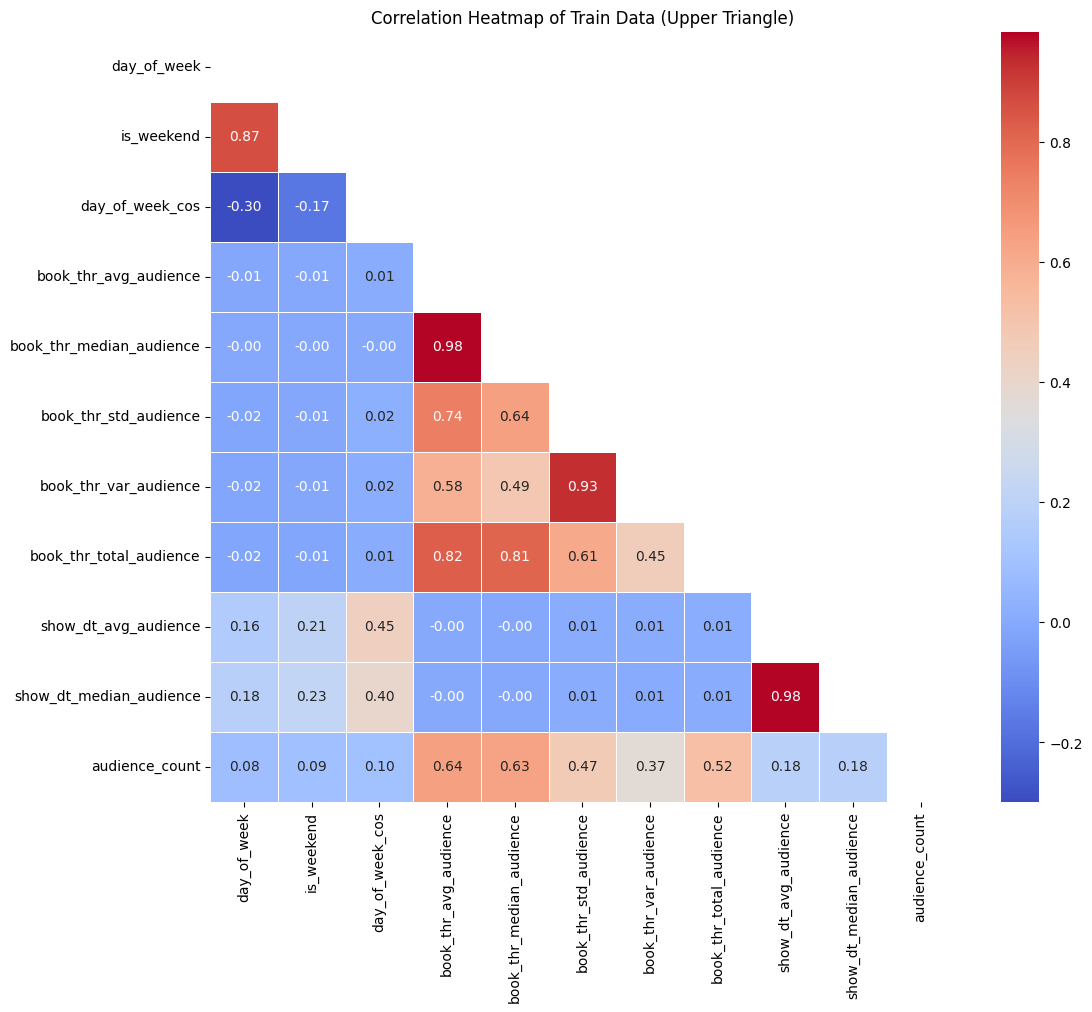

In [165]:
new_mat=pd.concat([X_train, y_train], axis=1)
corr_matrix = new_mat.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title('Correlation Heatmap of Train Data (Upper Triangle)')
plt.show()

# 4. FEATURE SELECTION METHODS

## 4.1 VarianceThreshold

In [166]:
from sklearn.feature_selection import VarianceThreshold

f_selector = VarianceThreshold(threshold=0.07)
f_selector.fit(X_train)
selected_mask = f_selector.get_support()
selected_mask

#selected_features = X.columns[selected_mask]
#X_selected = X[selected_features]

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])

## 4.2 MI-Regression

In [168]:
# MI REG -FE
from sklearn.feature_selection import mutual_info_regression, RFE
from sklearn.linear_model import LinearRegression

num_cols=X_train.select_dtypes(include='number').columns.tolist()
X = X_train[num_cols]
y = y_train

mi = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi, index=num_cols).sort_values(ascending=False)
print("Mutual Information Scores:")
print(mi_series)

Mutual Information Scores:
book_thr_var_audience       0.418840
book_thr_std_audience       0.417005
book_thr_avg_audience       0.403745
book_thr_total_audience     0.389863
book_thr_median_audience    0.337500
show_dt_avg_audience        0.027374
day_of_week                 0.019671
show_dt_median_audience     0.015089
day_of_week_cos             0.003539
is_weekend                  0.002786
dtype: float64


## 4.3 RFE FEAUTURE SELECTION

In [169]:
model = LinearRegression()
rfe = RFE(model, n_features_to_select=10)  # select top 9 features (tune as needed)
rfe.fit(X_train, y_train)

rfe_features = pd.Series(rfe.support_, index=X_train.columns)
selected_rfe = rfe_features[rfe_features].index.tolist()
print("\n Top Features from RFE:")
print(selected_rfe)

print(rfe.ranking_)


 Top Features from RFE:
['day_of_week', 'is_weekend', 'day_of_week_cos', 'book_thr_avg_audience', 'book_thr_median_audience', 'book_thr_std_audience', 'book_thr_var_audience', 'book_thr_total_audience', 'show_dt_avg_audience', 'show_dt_median_audience']
[1 1 1 1 1 1 1 1 1 1]


## 4.4 FEATURE IMPORTANCES-Ensemble models

In [170]:
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
LGBR = LGBMRegressor()
LGBR.fit(X_train, y_train)
LGB_importances = pd.Series(LGBR.feature_importances_, index=LGBR.feature_names_in_).sort_values(ascending=False)
print("\n LGBM Regressor Feature Importances:")
print(LGB_importances)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017809 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1381
[LightGBM] [Info] Number of data points in the train set: 197669, number of used features: 10
[LightGBM] [Info] Start training from score 41.304221

 LGBM Regressor Feature Importances:
show_dt_avg_audience        574
book_thr_std_audience       543
book_thr_avg_audience       521
book_thr_median_audience    449
day_of_week                 377
book_thr_total_audience     367
show_dt_median_audience      92
day_of_week_cos              77
is_weekend                    0
book_thr_var_audience         0
dtype: int32


## 4.5 Permutation Importance- HGBR
* Measures how much each feature contributes to prediction accuracy by shuffling it and checking the drop in performance.

In [171]:
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import SelectFromModel

hgb = HistGradientBoostingRegressor(random_state=42)
hgb.fit(X_train, y_train)

result = permutation_importance(hgb, X_test, y_test, n_repeats=11, random_state=42, n_jobs=-1)

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": result.importances_mean
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance (via Permutation Importance):")
print(feature_importance)


Feature Importance (via Permutation Importance):
                    Feature  Importance
3     book_thr_avg_audience    0.751962
4  book_thr_median_audience    0.112942
8      show_dt_avg_audience    0.059222
0               day_of_week    0.042125
5     book_thr_std_audience    0.029203
2           day_of_week_cos    0.016764
7   book_thr_total_audience    0.014408
9   show_dt_median_audience    0.005422
6     book_thr_var_audience    0.000008
1                is_weekend    0.000000


# 5. Preprocessing - Scaling 
* (Stad scaler, MinMax) with Pipeline

In [172]:
X_train.columns

Index(['day_of_week', 'is_weekend', 'day_of_week_cos', 'book_thr_avg_audience',
       'book_thr_median_audience', 'book_thr_std_audience',
       'book_thr_var_audience', 'book_thr_total_audience',
       'show_dt_avg_audience', 'show_dt_median_audience'],
      dtype='object')

In [173]:
pipe1 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())])

X_train_trans=pipe1.fit_transform(X_train)
X_test_trans=pipe1.transform(X_test)
test_data_cleaned_trans=pipe1.transform(test_data_cleaned)

X_train = pd.DataFrame(X_train_trans, columns=X_train.columns)
X_test = pd.DataFrame(X_test_trans, columns=X_train.columns)
test_data_cleaned = pd.DataFrame(test_data_cleaned_trans, columns=X_train.columns)

In [146]:
X_train.columns

Index(['day_of_week', 'is_weekend', 'day_of_week_cos', 'book_thr_avg_audience',
       'book_thr_median_audience', 'book_thr_std_audience',
       'book_thr_var_audience', 'book_thr_total_audience',
       'show_dt_avg_audience', 'show_dt_median_audience',
       'show_dt_std_audience', 'booking_tickets_sum'],
      dtype='object')

In [174]:
X_train.head()

,day_of_week,is_weekend,day_of_week_cos,book_thr_avg_audience,book_thr_median_audience,book_thr_std_audience,book_thr_var_audience,book_thr_total_audience,show_dt_avg_audience,show_dt_median_audience
0,1.437191,1.081739,0.937983,-0.992597,-0.889135,-1.032355,-0.671691,-0.475839,0.191706,-0.954593
1,1.437191,1.081739,0.937983,0.027236,-0.313266,1.772005,1.541620,0.060410,0.191706,-0.954593
2,1.437191,1.081739,0.937983,0.012692,-0.025331,0.979584,0.641146,0.600229,0.191706,-0.954593
3,1.437191,1.081739,0.937983,-0.658376,-0.601200,-0.476422,-0.448584,-0.097003,0.191706,-0.954593
4,1.437191,1.081739,0.937983,1.698399,1.222386,2.427963,2.450937,2.856483,0.191706,-0.954593


# 6. MODEL TRAINING AND EVALUATING

* I prefer boosting models as Boosting handles complex, non-linear patterns, and large datasets.
* Boosting builds models sequentially:

* Model 1 makes an initial prediction
* Model 2 tries to correct Model 1’s mistakes
* Model 3 corrects leftover mistakes, 
Continue until errors reduce. So boosting = error-correcting models.

In [175]:
from sklearn.ensemble import VotingRegressor

reg1 = HistGradientBoostingRegressor(warm_start=True,random_state=42)
reg2 = LGBMRegressor(random_state=42)
reg3 = XGBRegressor(random_state=42)
#reg4= RandomForestRegressor(random_state=42)


voting_reg = VotingRegressor(estimators=[('hist', reg1), ('lgbm', reg2), ('xgb', reg3)])

voting_reg.fit(X_train, y_train)
y_pred_voting = voting_reg.predict(X_test)

mae_voting = mean_absolute_error(y_test, y_pred_voting)
mse_voting = mean_squared_error(y_test, y_pred_voting)
rmse_voting=np.sqrt(mse_voting)
r2_voting = r2_score(y_test, y_pred_voting)

print(f"Voting Regressor Performance on Test Set:")
print(f"Mean Absolute Error (MAE): {mae_voting:.4f}")
print(f"Mean Squared Error (MSE): {mse_voting:.4f}")
print(f"Root Mean Squared Error (MSE): {rmse_voting:.4f}")
print(f"R-squared (R2) Score: {r2_voting:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003976 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1399
[LightGBM] [Info] Number of data points in the train set: 197669, number of used features: 10
[LightGBM] [Info] Start training from score 41.304221
Voting Regressor Performance on Test Set:
Mean Absolute Error (MAE): 16.5412
Mean Squared Error (MSE): 582.8500
Root Mean Squared Error (MSE): 24.1423
R-squared (R2) Score: 0.5188


## 6.1 Visualizing the model performance

In [38]:
# fig,axes = plt.subplots(nrows=2,ncols=5,figsize=(16,6))
# plt.suptitle('X Features with Target columns', fontsize = 30)

# axes[0,0].plot(X_train.iloc[:,0],y_train,'b')
# axes[0,1].plot(X_train.iloc[:,1],y_train,'g')
# axes[0,2].plot(X_train.iloc[:,2],y_train,'r')
# axes[0,3].plot(X_train.iloc[:,3],y_train,'black')
# axes[0,4].plot(X_train.iloc[:,4],y_train,'pink')
# #axes[0].set_ylabel("Expenditures", fontsize = 15)

# axes[1,0].plot(X_train.iloc[:,0],y_train,'orange')
# axes[1,1].plot(X_train.iloc[:,1],y_train,'brown')
# axes[1,2].plot(X_train.iloc[:,2],y_train,'lightgreen')
# axes[1,3].plot(X_train.iloc[:,3],y_train,'gray')
# axes[1,4].plot(X_train.iloc[:,4],y_train,'mo')

# plt.tight_layout()
# plt.show()

In [150]:
# models={
#     #'lin_reg': LinearRegression(),
#     #'Ridge': Ridge(),
#     #'Lasso': Lasso(),
#     'XGB': XGBRegressor(),
#     'LGB': LGBMRegressor(),
#     #'SGD': SGDRegressor(),
#     #'Tree': DecisionTreeRegressor(),
#     #'Ran_Forest': RandomForestRegressor(),
#     #'GBR': GradientBoostingRegressor(),
#     'HXGB': HistGradientBoostingRegressor(warm_start=True)
#     #'svr': SVR()
#     #'MLP': MLPRegressor()
# }

# for model_name, model in models.items():
#     print("-"*60)
#     print(f"model_name : {model_name}")
#     model.fit(X_train,y_train)
#     y_pred=model.predict(X_test)
#     MAE_Score=mean_absolute_error(y_test,y_pred)
#     MSE_Score=mean_squared_error(y_test,y_pred)
#     RMSE_score=np.sqrt(MSE_Score)
#     R2_Score=r2_score(y_test,y_pred)
#     print(f"MAE_Score: {MAE_Score},MSE_Score:{MSE_Score},RMSE_Score:{RMSE_score},R2_Score:{R2_Score}")

------------------------------------------------------------
model_name : XGB
MAE_Score: 16.50500061720739,MSE_Score:585.9720521920171,RMSE_Score:24.20685961028438,R2_Score:0.5161852785140418
------------------------------------------------------------
model_name : LGB
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005377 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1806
[LightGBM] [Info] Number of data points in the train set: 197679, number of used features: 12
[LightGBM] [Info] Start training from score 41.302981
MAE_Score: 16.721269934229436,MSE_Score:594.2552791936006,RMSE_Score:24.377351767441855,R2_Score:0.5093461346508071
------------------------------------------------------------
model_name : HXGB
MAE_Score: 16.68245115079484,MSE_Score:591.4652214000125,RMSE_Score:24.320058005687663,R2_Score:0.5116497787056471


## 6.2. Model Performance Comparison

In [176]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

models = {
    'XGB': XGBRegressor(),
    'LGB': LGBMRegressor(),
    'HXGB': HistGradientBoostingRegressor()}

train_results={"Model":[], "MAE": [], "MSE":[], "RMSE":[], "R2":[]}
test_results = {"Model":[], "MAE": [], "MSE":[], "RMSE":[], "R2":[]}

for model_name, model in models.items():
    print("-" * 60)

    model.fit(X_train, y_train)
    y_pred_train=model.predict(X_train)
    y_pred_test = model.predict(X_test)

    MAE_Score1 = mean_absolute_error(y_train, y_pred_train)
    MSE_Score1 = mean_squared_error(y_train, y_pred_train)
    RMSE_Score1 = np.sqrt(MSE_Score)
    R2_Score1 = r2_score(y_train, y_pred_train)
    
    MAE_Score2 = mean_absolute_error(y_test, y_pred_test)
    MSE_Score2 = mean_squared_error(y_test, y_pred_test)
    RMSE_Score2 = np.sqrt(MSE_Score)
    R2_Score2 = r2_score(y_test, y_pred_test)
    
    train_results["Model"].append(model_name)
    train_results["MAE"].append(MAE_Score1)
    train_results["MSE"].append(MSE_Score1)
    train_results["RMSE"].append(RMSE_Score1)
    train_results["R2"].append(R2_Score1)
    
    
    test_results["Model"].append(model_name)
    test_results["MAE"].append(MAE_Score2)
    test_results["MSE"].append(MSE_Score2)
    test_results["RMSE"].append(RMSE_Score2)
    test_results["R2"].append(R2_Score2)

print(f"Training Model: {model_name}")
df_train_results = pd.DataFrame(train_results)
print(df_train_results)
print("")

print(f"Validation Model: {model_name}")
df_test_results = pd.DataFrame(test_results)
print(df_test_results)

------------------------------------------------------------
------------------------------------------------------------
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003970 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1399
[LightGBM] [Info] Number of data points in the train set: 197669, number of used features: 10
[LightGBM] [Info] Start training from score 41.304221
------------------------------------------------------------
Training Model: HXGB
  Model        MAE         MSE       RMSE        R2
0   XGB  14.279841  430.585028  24.365375  0.596016
1   LGB  15.069849  502.214018  24.365375  0.528812
2  HXGB  15.070118  503.114595  24.365375  0.527967

Validation Model: HXGB
  Model        MAE         MSE       RMSE        R2
0   XGB  16.457603  583.288615  24.365375  0.518401
1   LGB  16.705896  592.278733  24.365375  0.510978


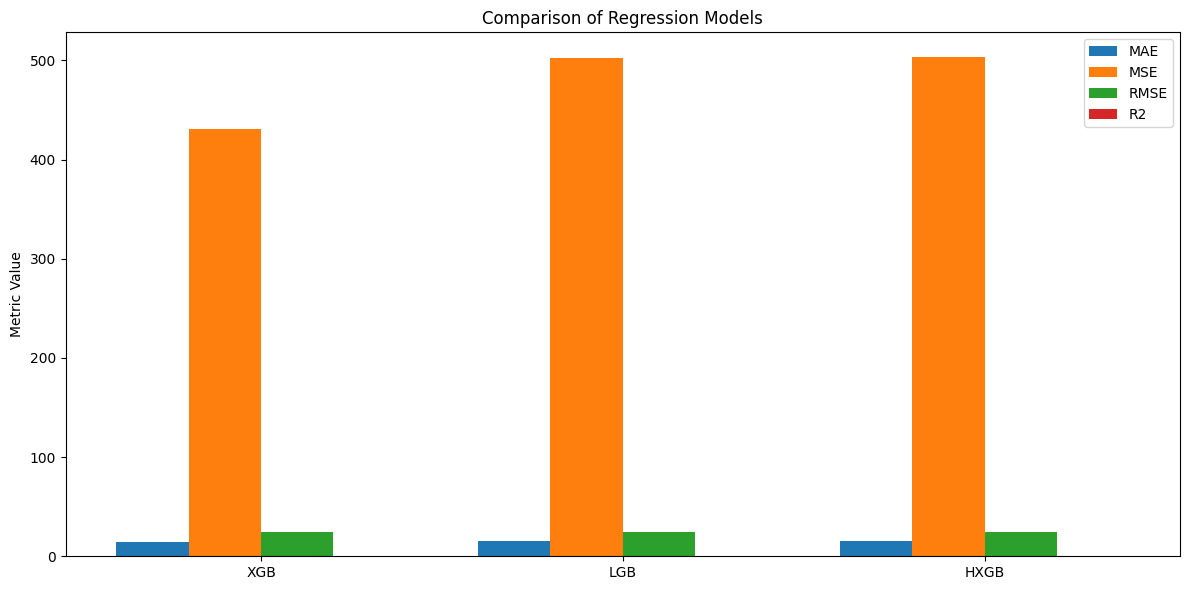

In [178]:
plt.figure(figsize=(12, 6))

x = np.arange(len(df_train_results["Model"]))
width = 0.2

plt.bar(x - width*1.5, df_train_results["MAE"], width, label="MAE")
plt.bar(x - width*0.5, df_train_results["MSE"], width, label="MSE")
plt.bar(x + width*0.5, df_train_results["RMSE"], width, label="RMSE")
plt.bar(x + width*1.5, df_train_results["R2"], width, label="R2")

plt.xticks(x, df_train_results["Model"])
plt.ylabel("Metric Value")
plt.title("Comparison of Regression Models")
plt.legend()
plt.tight_layout()
plt.show()

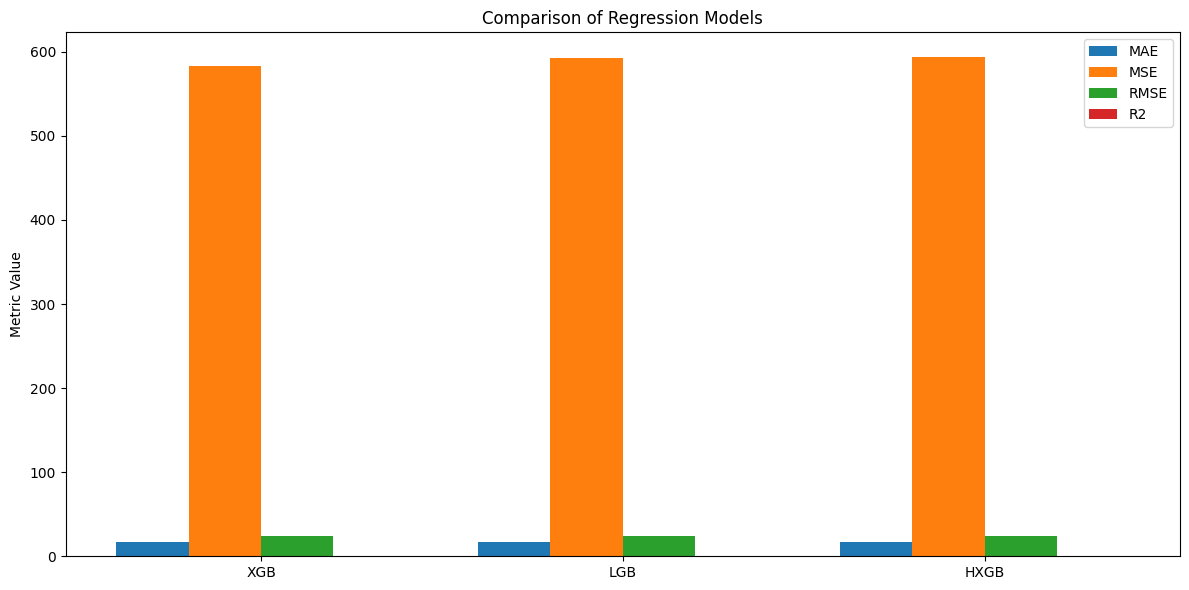

In [177]:
plt.figure(figsize=(12, 6))

x = np.arange(len(df_test_results["Model"]))
width = 0.2

plt.bar(x - width*1.5, df_test_results["MAE"], width, label="MAE")
plt.bar(x - width*0.5, df_test_results["MSE"], width, label="MSE")
plt.bar(x + width*0.5, df_test_results["RMSE"], width, label="RMSE")
plt.bar(x + width*1.5, df_test_results["R2"], width, label="R2")

plt.xticks(x, df_test_results["Model"])
plt.ylabel("Metric Value")
plt.title("Comparison of Regression Models")
plt.legend()
plt.tight_layout()
plt.show()

In [149]:
from sklearn.ensemble import BaggingRegressor
from sklearn.experimental import enable_hist_gradient_boosting # Explicitly enable the experimental module

base_estimator = HistGradientBoostingRegressor(warm_start=True,random_state=42)

bagging_reg1 = BaggingRegressor(estimator=base_estimator, random_state=42, n_estimators=10) # You can adjust n_estimators

bagging_reg1.fit(X_train, y_train)
y_pred_bagging = bagging_reg1.predict(X_test)

mae_bagging = mean_absolute_error(y_test, y_pred_bagging)
mse_bagging = mean_squared_error(y_test, y_pred_bagging)
rmse_voting=np.sqrt(mse_bagging)
r2_bagging = r2_score(y_test, y_pred_bagging)

print(f"Bagging Regressor Performance on Test Set:")
print(f"Mean Absolute Error (MAE): {mae_bagging:.4f}")
print(f"Mean Squared Error (MSE): {mse_bagging:.4f}")
print(f"Root Mean Squared Error (MSE): {rmse_voting:.4f}")
print(f"R-squared (R2) Score: {r2_bagging:.4f}")

Bagging Regressor Performance on Test Set:
Mean Absolute Error (MAE): 16.7286
Mean Squared Error (MSE): 594.4573
Root Mean Squared Error (MSE): 24.3815
R-squared (R2) Score: 0.5092


In [ ]:
# lgbm_model1 = LGBMRegressor(
#         n_estimators=1000,
#         learning_rate=0.05,
#         max_depth=8,
#         num_leaves=31,
#         subsample=0.8,
#         colsample_bytree=0.8,
#         reg_alpha=0.1,
#         reg_lambda=0.1,
#         random_state=0,
#         n_jobs=-1)
# lgbm_model1.fit(X_train,y_train)
# y_pred_lgbm=lgbm_model1.predict(X_test)
# R2_Score=r2_score(y_test,y_pred_lgbm)
# print("R2_Score:",R2_Score)

In [77]:
# xgb_model1 = XGBRegressor(
#         n_estimators=500,
#         learning_rate=0.05,
#         max_depth=6,
#         subsample=0.8,
#         colsample_bytree=0.8,
#         reg_alpha=0.1,
#         reg_lambda=0.1,
#         random_state=42,
#         n_jobs=-1
#     )
# xgb_model1.fit(X_train,y_train)
# y_pred_xgb=xgb_model1.predict(X_test)
# R2_Score=r2_score(y_test,y_pred_xgb)
# print("R2_Score:",R2_Score)

R2_Score: 0.4928021879727559


In [78]:
# from sklearn.ensemble import HistGradientBoostingRegressor
# from sklearn.metrics import r2_score

# hgb_model1 = HistGradientBoostingRegressor(
#     learning_rate=0.01,        
#     max_depth=10,               
#     max_leaf_nodes=31,         
#     min_samples_leaf=15,       
#     l2_regularization=0.1,     
#     max_bins=255,              
#     early_stopping=True,       
#     validation_fraction=0.1,   
#     n_iter_no_change=20,      
#     scoring='r2',
#     warm_start=True,
#     random_state=42)

# hgb_model1.fit(X_train, y_train)

# y_pred_hgb = hgb_model1.predict(X_test)
# R2_Score_hgb = r2_score(y_test, y_pred_hgb)
# print("R2_Score (HistGradientBoosting):", R2_Score_hgb)


R2_Score (HistGradientBoosting): 0.3750019868786033


# 7. HYPER-PARAMETER TUNING

In [ ]:
# model = HistGradientBoostingRegressor(random_state=42)
# param_grid = {
#     'learning_rate': [0.01, 0.05, 0.1],
#     #'max_depth': [3, 5, 7],
#     'max_leaf_nodes': [15, 31],
#     'min_samples_leaf': [10, 20, 30],
#     'l2_regularization': [0.0, 0.1, 1.0],
#     'max_iter': [100, 300, 500]
# }

# grid_search = GridSearchCV(
#     estimator=model,
#     param_grid=param_grid,
#     cv=3,
#     scoring='neg_mean_absolute_error',  # or 'r2' / 'neg_mean_squared_error'
#     n_jobs=-1,
#     verbose=2)

# grid_search.fit(X_train, y_train)
# print("Best parameters:", grid_search.best_params_)

# best_model = grid_search.best_estimator_

In [179]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

xgb = XGBRegressor(random_state=42, tree_method='hist')

param_grid = {
    'n_estimators': [200, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9]
}

grid = GridSearchCV(estimator=xgb, param_grid=param_grid,cv=3, scoring='neg_mean_absolute_error',n_jobs=-1,verbose=2)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
best_model=grid.best_estimator_

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.9}


# 8. BEST MODEL SELECTION

In [180]:
best_model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=7, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [181]:
# best_model=XGBRegressor(warm_start=True,random_state=42)
# best_model.fit(X_train,y_train)
#test_pred=best_model.predict(test_data_cleaned)

test_pred=best_model.predict(test_data_cleaned)
test_pred=np.clip(test_pred, 0, None)
test_pred = np.ceil(test_pred)  # Rounds each value to 2 decimal points
test_pred = test_pred.ravel()

# 9. KAGGLE SUBMISSION
* FINAL PREDICTION TO SAVE AS SUBMISSION.CSV FOR KAGGLE SUBMISSION

In [182]:
submission = pd.DataFrame({
    "ID": sample_submission['ID'],
    "audience_count":test_pred
})
#submission.to_csv("submission.csv", index=False)
submission.to_csv('/kaggle/working/submission.csv', index=False)

submission.head(4)

,ID,audience_count
0,book_00001_2024-03-01,40.0
1,book_00001_2024-03-02,50.0
2,book_00001_2024-03-03,66.0
3,book_00001_2024-03-04,45.0


In [183]:
submission.audience_count.mean()

43.64813

[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.7; total time=   2.8s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=200, subsample=0.9; total time=   2.6s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=400, subsample=0.9; total time=   4.8s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=5, n_estimators=200, subsample=0.7; total time=   4.0s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=5, n_estimators=200, subsample=0.9; total time=   4.0s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=5, n_estimators=400, subsample=0.7; total time=   7.4s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=7, n_estimators=200, subsample=0.7; total time=   5.8s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=7, n_estimators=200, subsample=0.9; total time=   5.8s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=7, n_estima

In [ ]:
#Verify the file exists before submission
!ls -lh /kaggle/working

Boosting models automatically learn:

Weekends > weekdays

Festival days > normal days

Opening day spikes

Decline after a few days

Theatre-wise capacity differences

Show date → seasonal effects

Rolling features → trend

Lag features → autocorrelation

Linear models cannot learn these interactions without heavy manual feature engineering.

“I chose boosting models because my cinema audience data has strong non-linear patterns influenced by weekends, holidays, movie releases, and theatre IDs. Boosting models learn these complex relationships better than linear or bagging models.

Boosting works by sequentially adding small decision trees, each correcting the previous tree’s error. This makes the final model highly accurate.

Techniques like XGBoost, LightGBM, and HistGradientBoosting are perfect for tabular, feature-rich forecasting tasks and consistently outperform linear models, ARIMA, and Random Forest for this dataset.”